### Objective: ### 
Use the MSC dataset to find differences in FEF activity between visualization of indoor and outdoor scenes. Although the paper itself doesn't specify what kinds of images were used--for example, were the outdoor images of nature?--for their scene memory task, from the example image given, we can assume there is probably some nature in the outdoor scenes and isn't just an urban jungle.  The FEF, in conjunction with other brain regions, directs saccades, essentially controlling visual input into the brain.  Because we are hypothesizing that contextual differences govern FEF activity, its activity will contain information about that context.  Thus, instead of convolving the experimental design with the HRF, we are going to forego the GLM to discover the voxels that show the sort of activity expected from the presentation of the stimuli.

In [1]:
# ! cd ../ds000224 && chmod +x ./dl_files.sh && bash ./dl_files.sh

From downloading the files via git annex, we can see that some subjects did not do all tasks for each run.

| Subject | Run |
|---------|-----|
| MSC02 | 4 |
| MSC02 | 8 |
| MSC10 | 6 |

We will thus be excluding those runs from analysis.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mlp
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import nibabel as nib
import nilearn as nil
from nilearn.plotting import plot_epi
from nilearn.glm.first_level import make_first_level_design_matrix
# import siibra

Having imported the modules we need for now, we need to preprocess the data.  Preprocessing fMRI scans requires multiple steps that can be done manually, but to save time, we will use FMRIPrep.  This software does a decent job of preparing the scans for analysis, though we will have to check its work and maybe redo some manually in the event that its work is incorrect.

In [3]:
# This will take FOREVER.  Like about a day, if not a bit more.
# ! fmriprep-docker --fs-license-file /home/$USER/Documents/MSC/scripts/license.txt /home/tahia/Documents/MSC/ds000224 /home/tahia/Documents/MSC/derivatives participant -w /home/tahia/Documents/MSC/scratch --task-id memoryscenes --skip-bids-validation

First, let's set some variables up. We'll be using the wi

In [4]:
data_path = "../derivatives/"
subj_pref = "sub-MSC"
sess_pref = "ses-func"
task_suff = "task-memoryscenes"
space_suff = "space-MNI152NLin2009cAsym"
desc_suff = "desc-preproc_bold"
# atlas = siibra.atlases.get('human')

We are going to start by visualizing a random selection of the preprocessed brains to get an idea of how well FMRIPrep handled the data. Generally, it is better to individually go through each scan manually (something you'd have to do even if you didn't use FMRIPrep) to make sure that the brains were warped such that they still resemble brains. We are not going to get cytoarchitectonics level detail here, so, despite the tediousness of examining every single scan, it's actually very easy and quick to do.

In [29]:
bold_vis_check_files = []
random_subjects = np.random.randint(0,9,5)
for s in random_subjects:
    runs = np.random.randint(0,10,3)
    for r in runs:
        if r==10:
            r="10"
        else:
            r='0'+str(r)

        bold_img_name = subj_pref + "0" + str(s) + "_" + sess_pref + r + bold_suff
        path = data_path + subj_pref + "0" + str(s) + "/" + sess_pref + r + "/func/" +  bold_img_name
        if os.path.isfile(path):
            bold_vis_check_files.append(path)

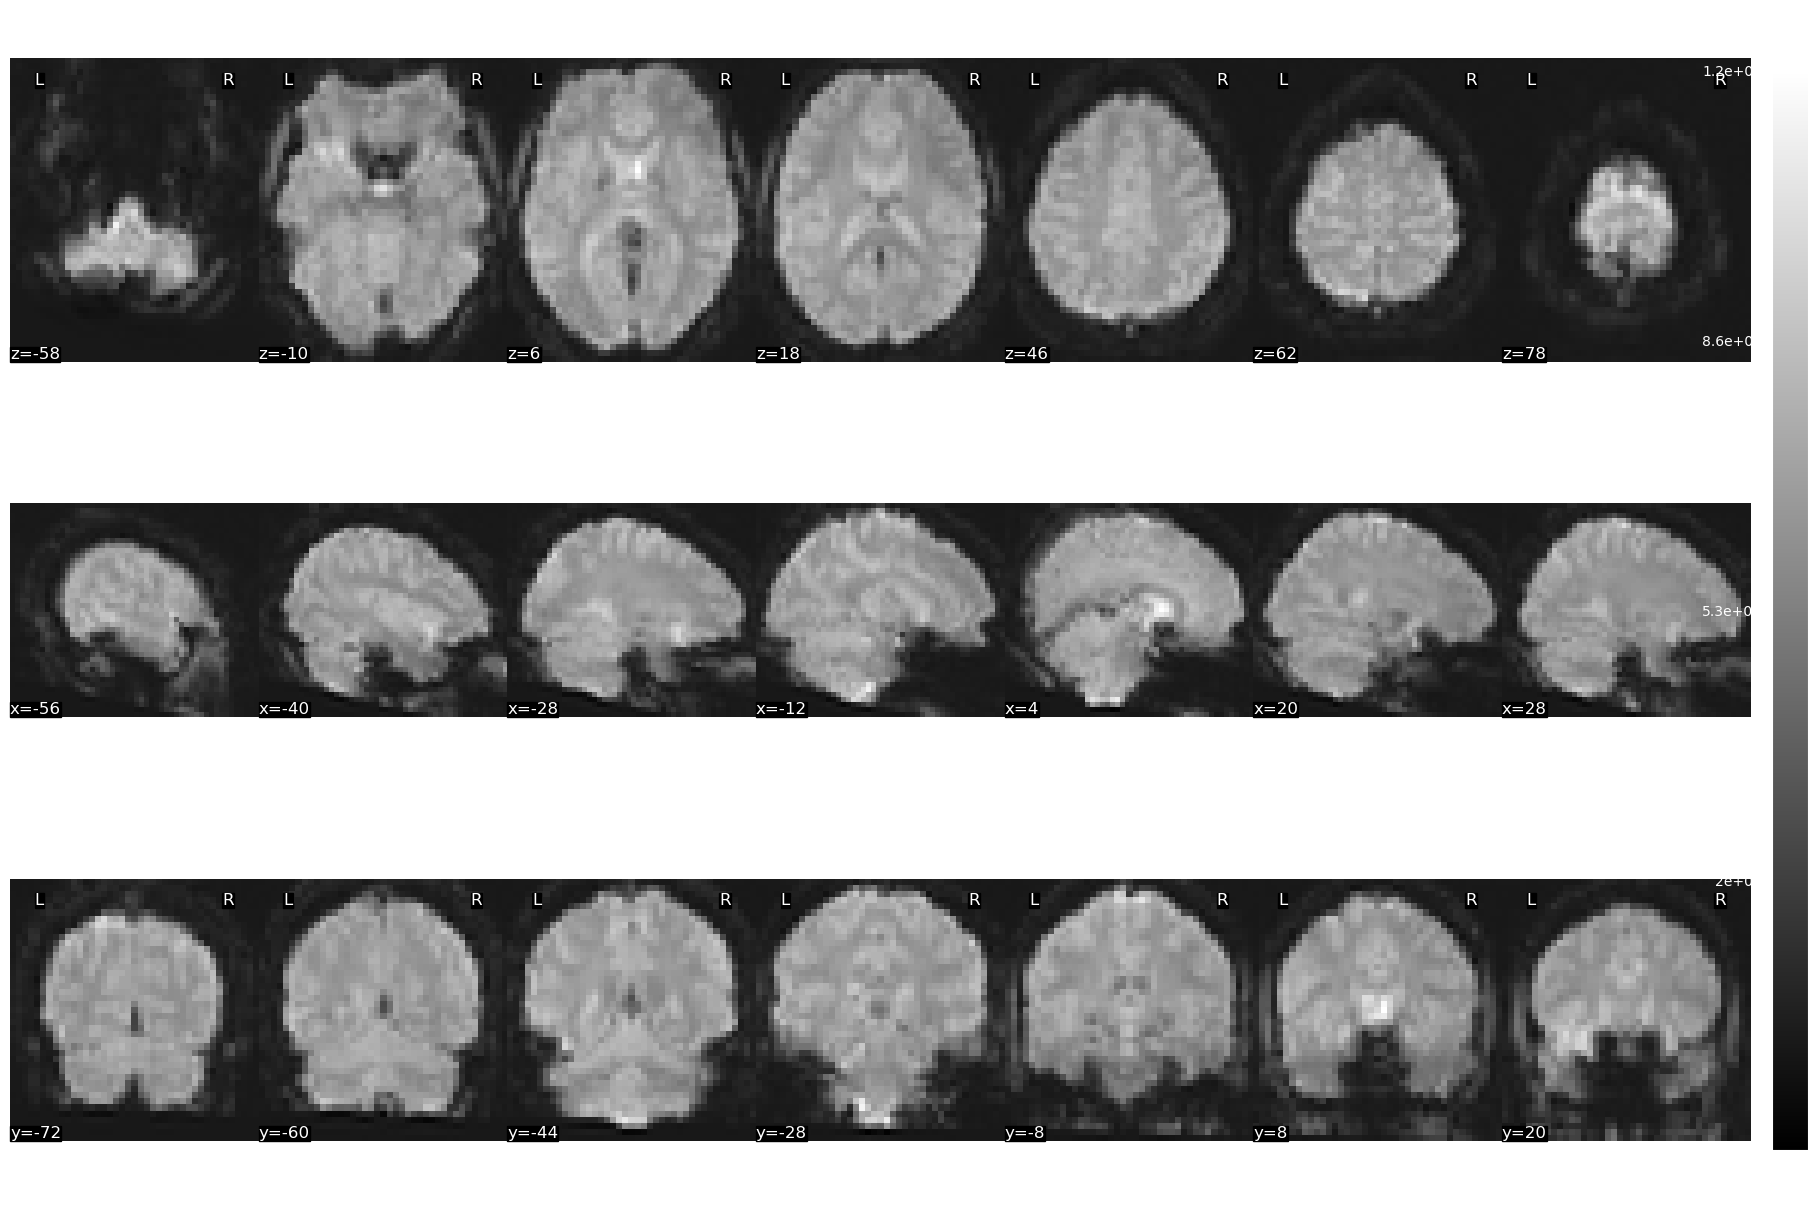

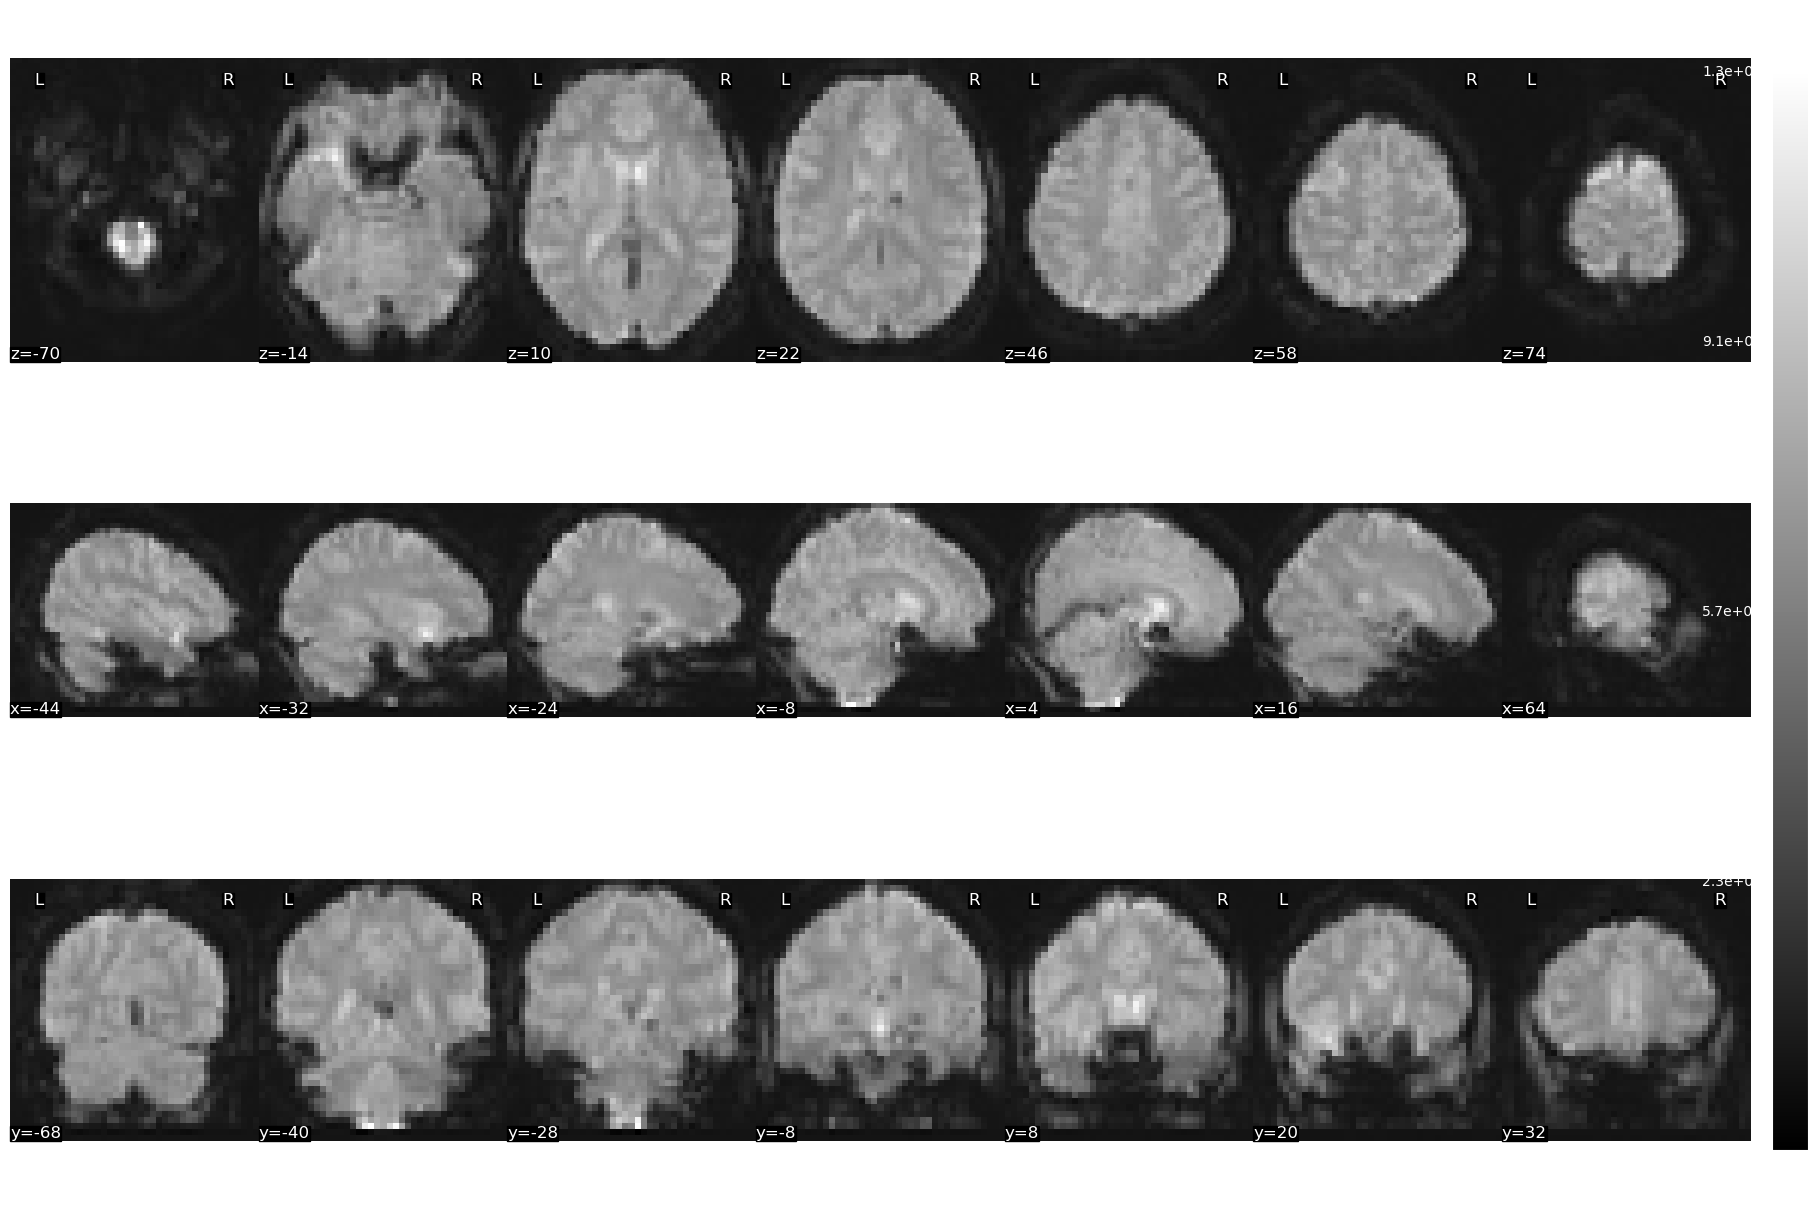

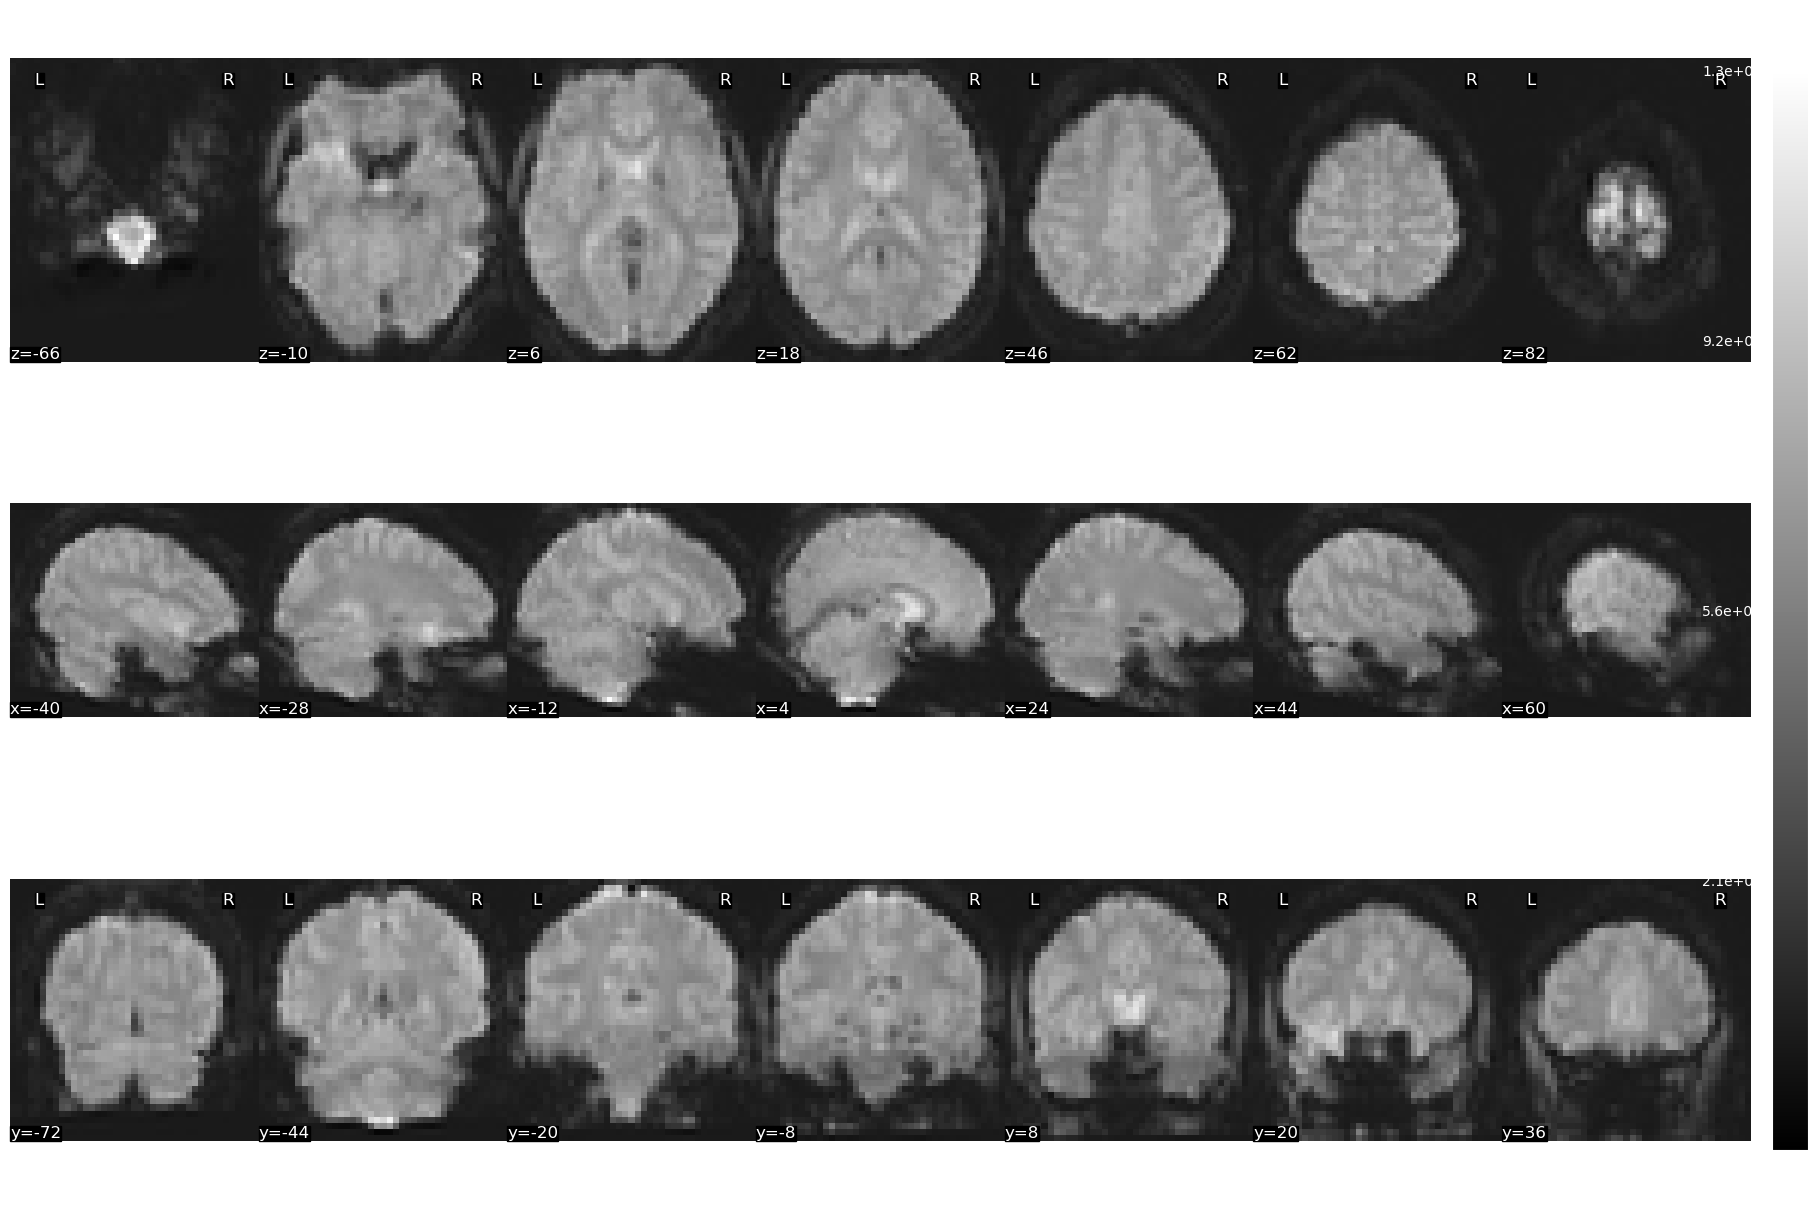

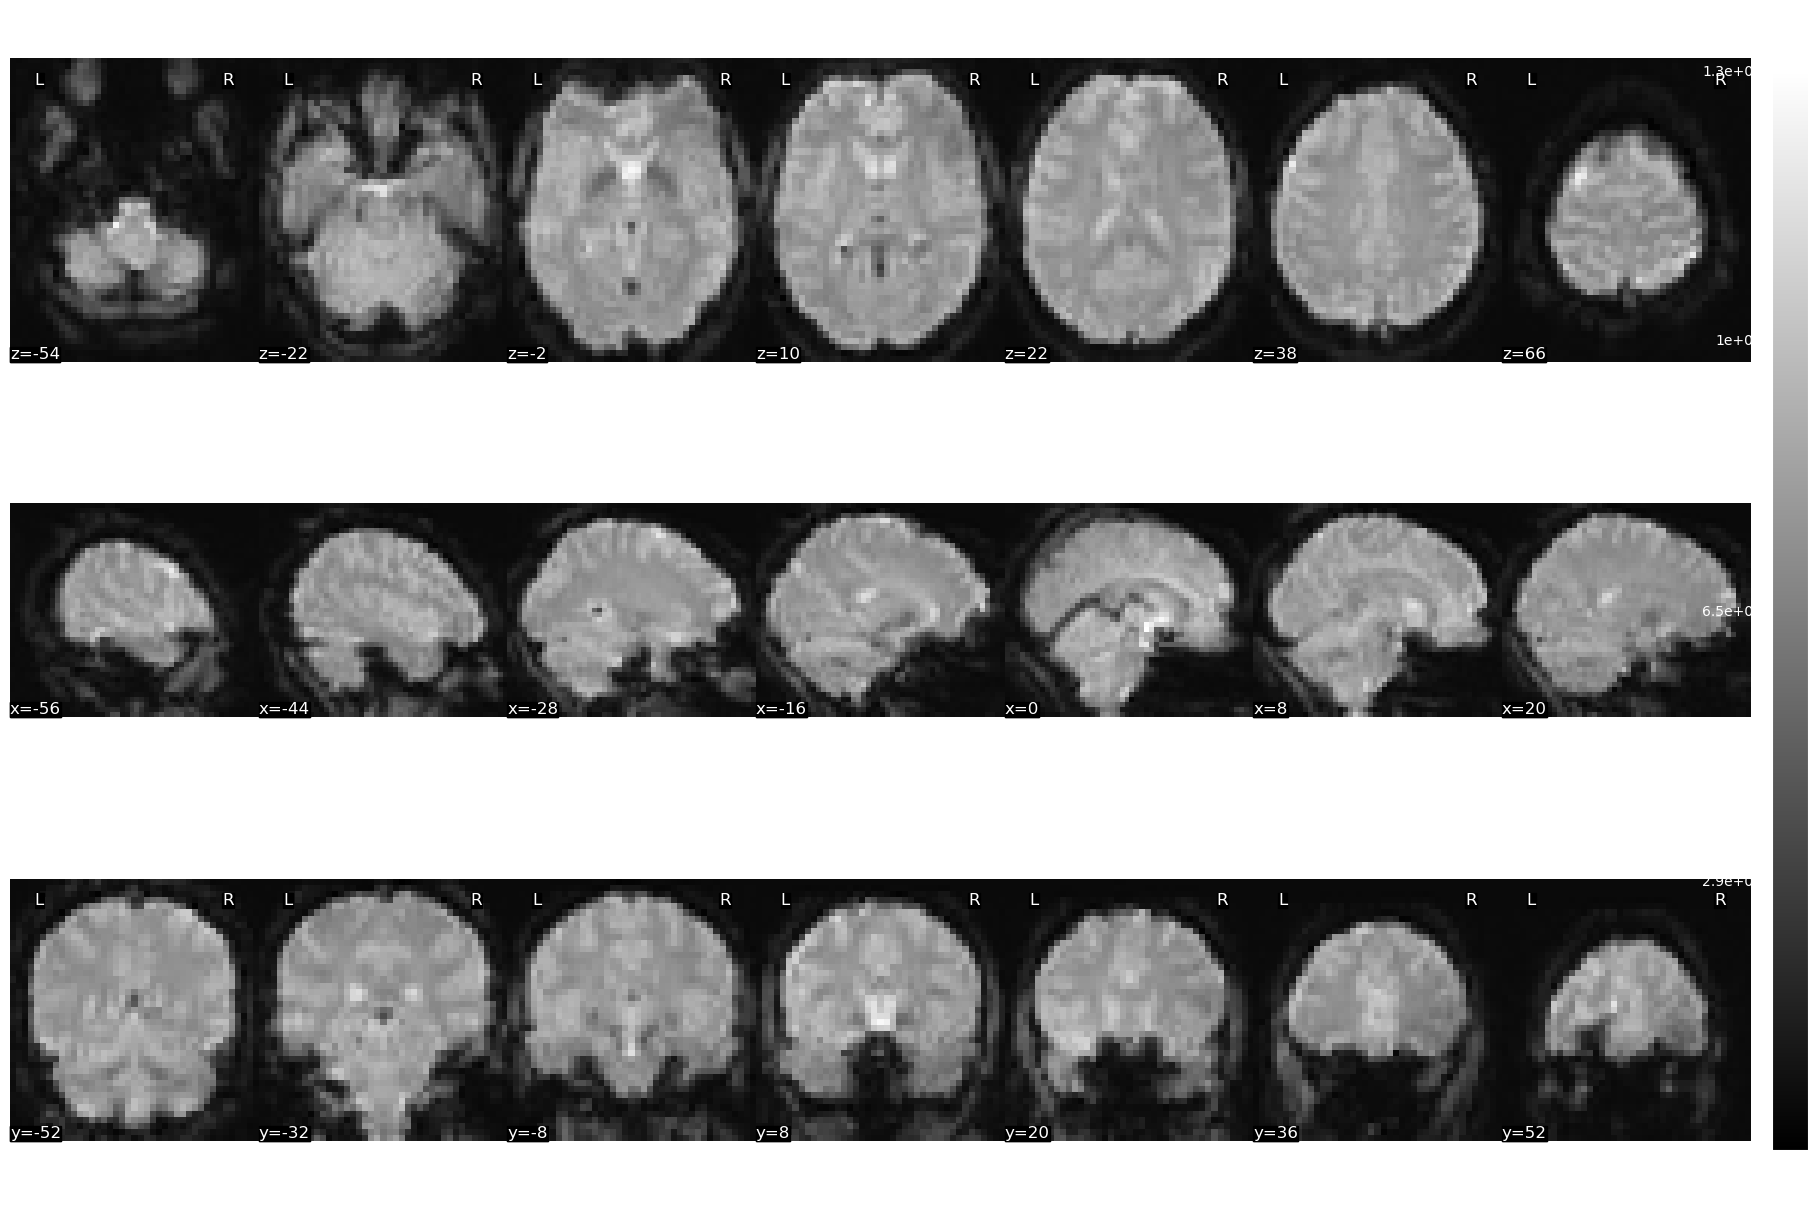

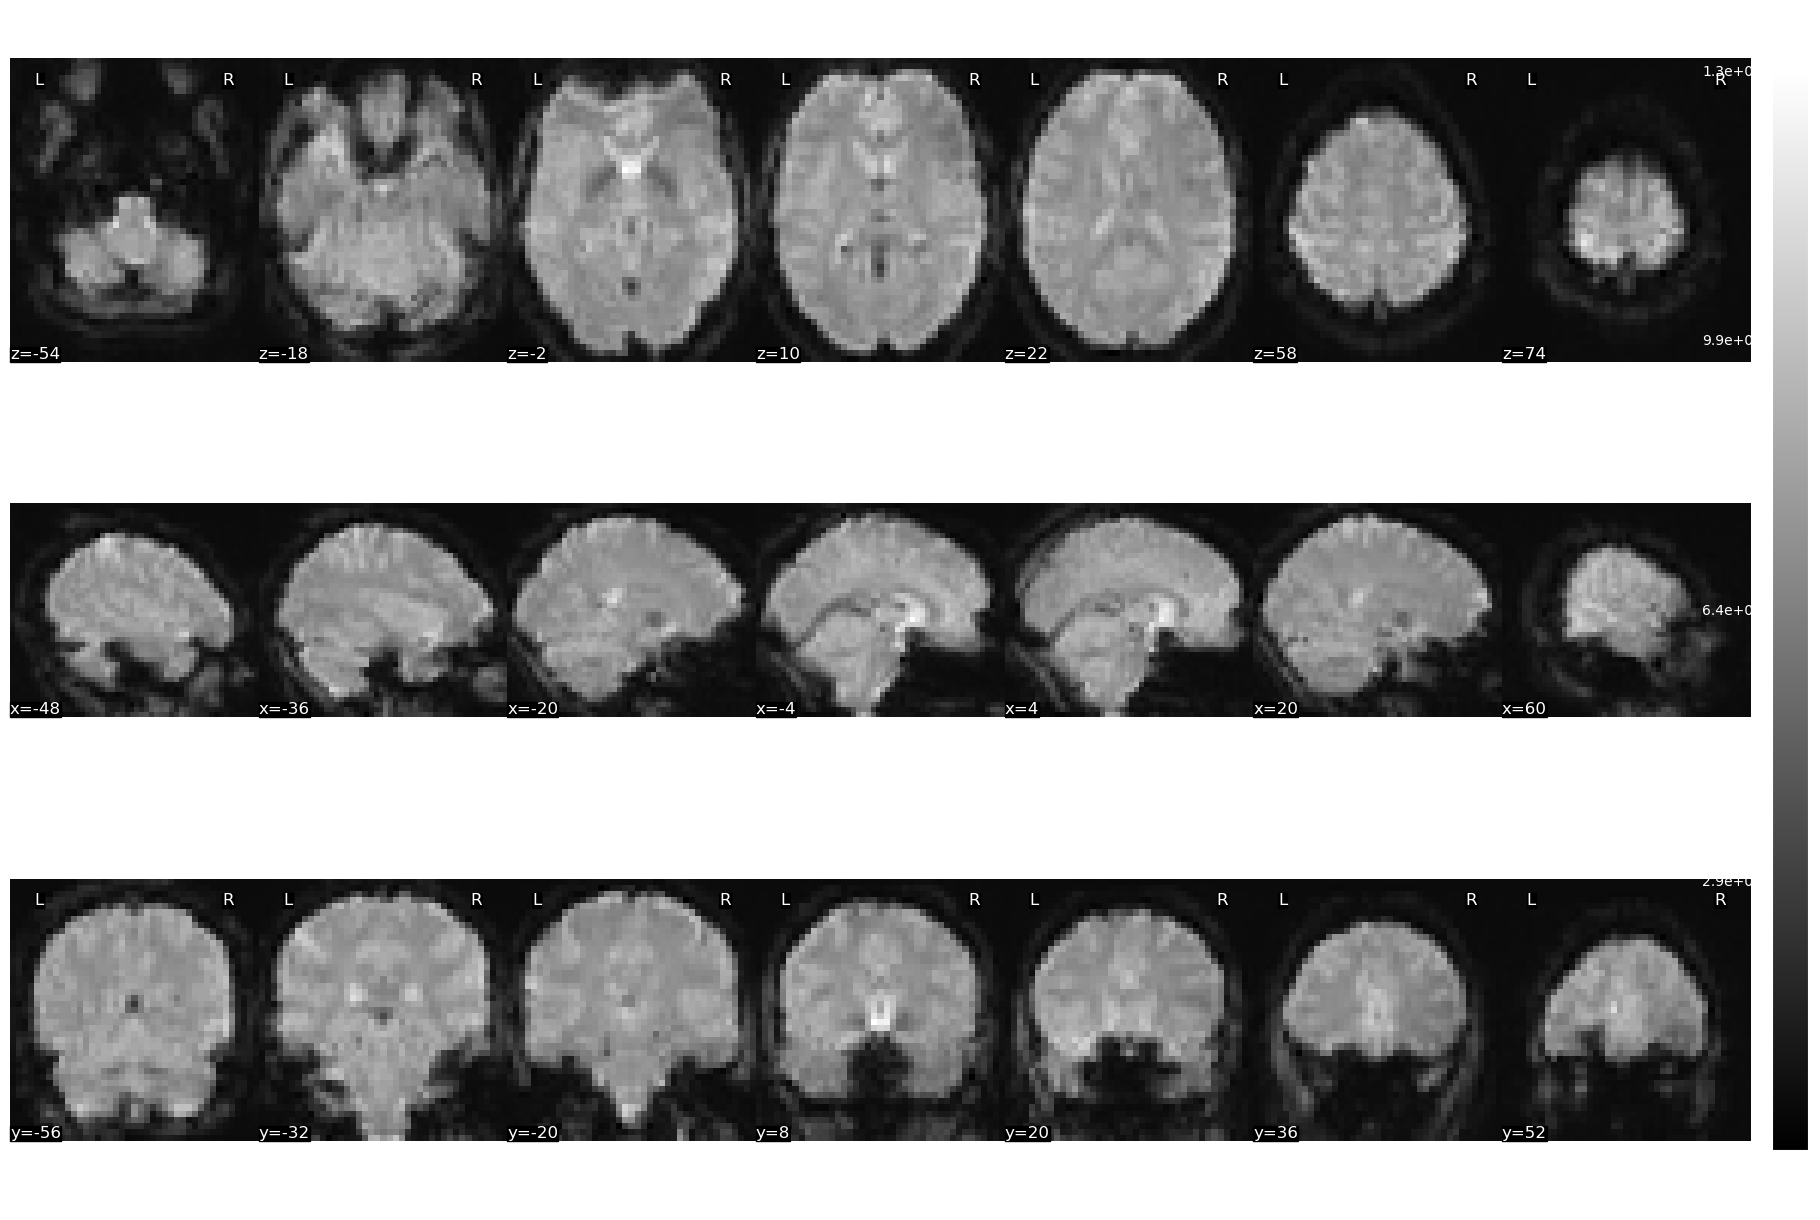

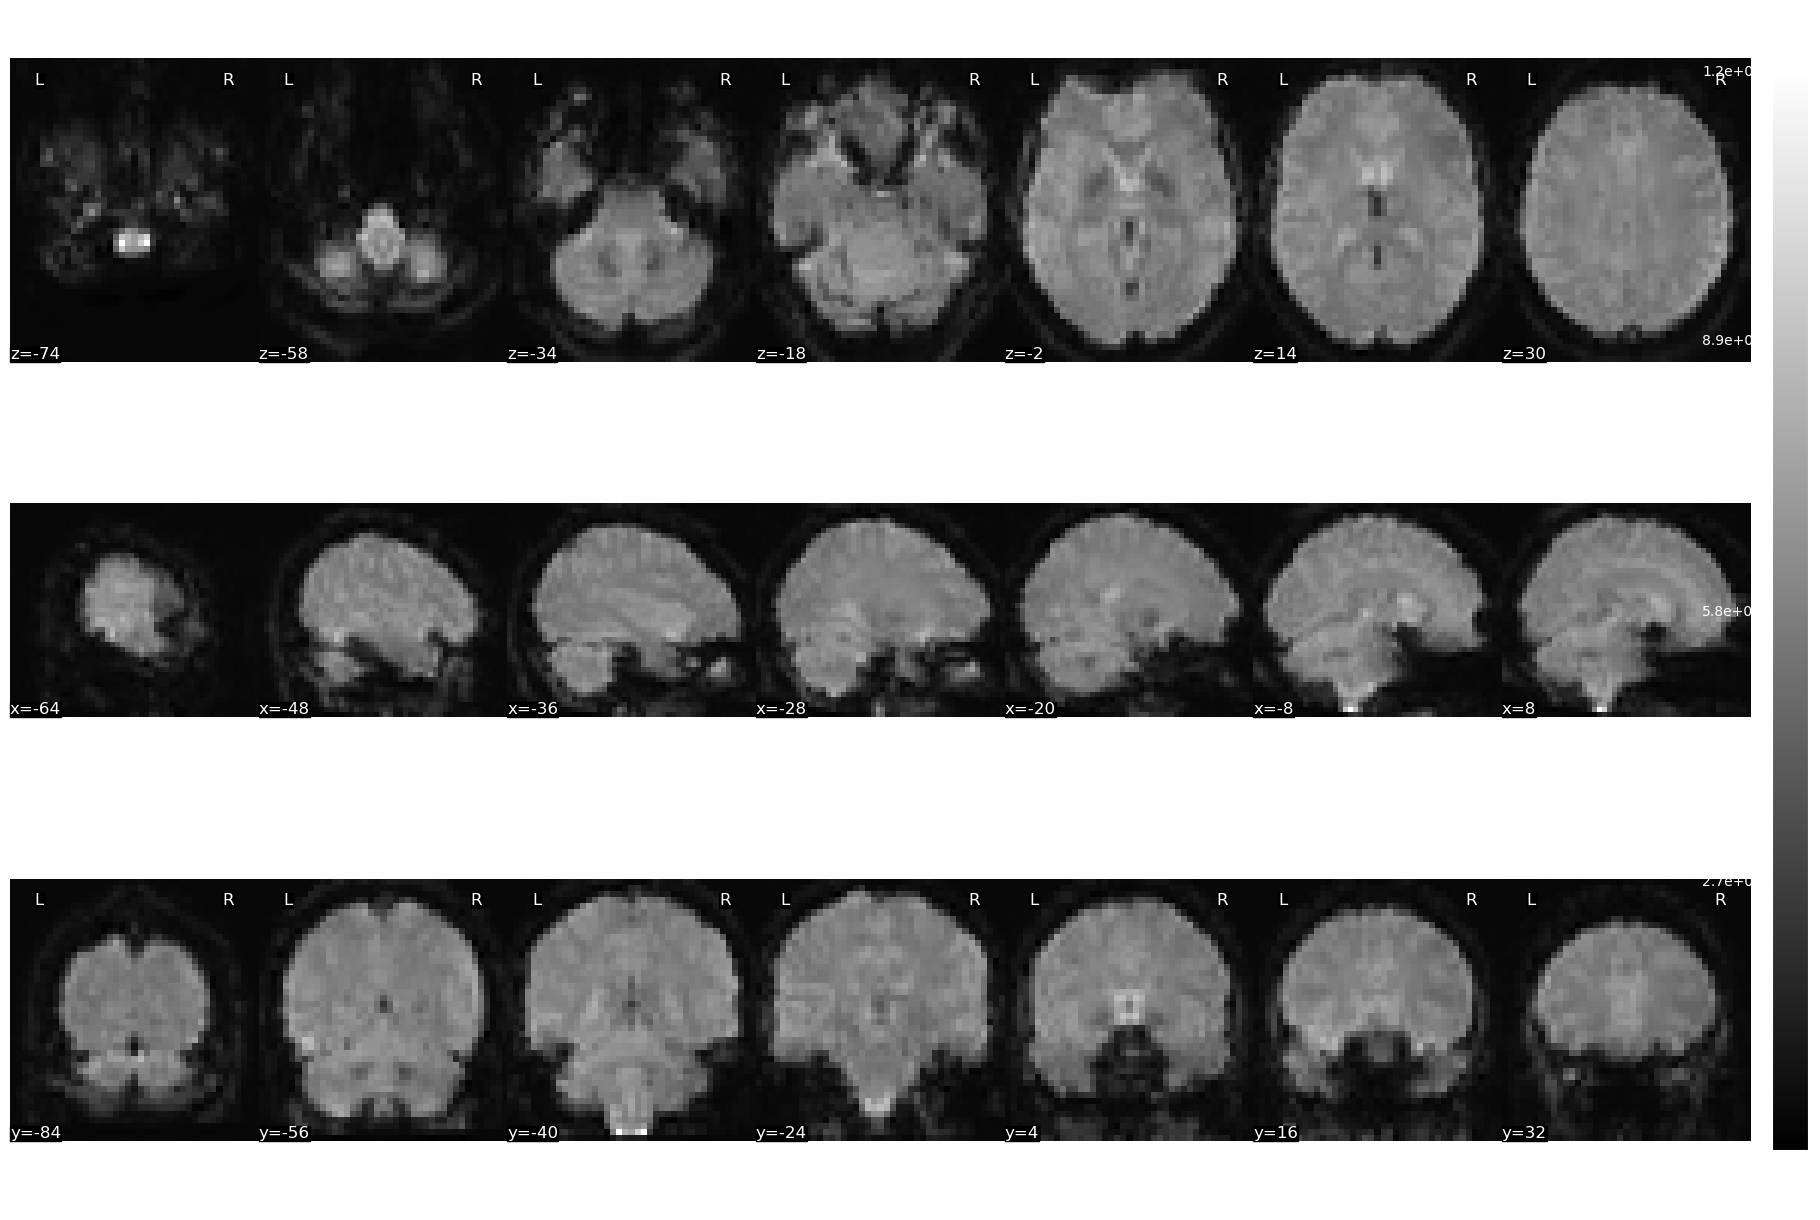

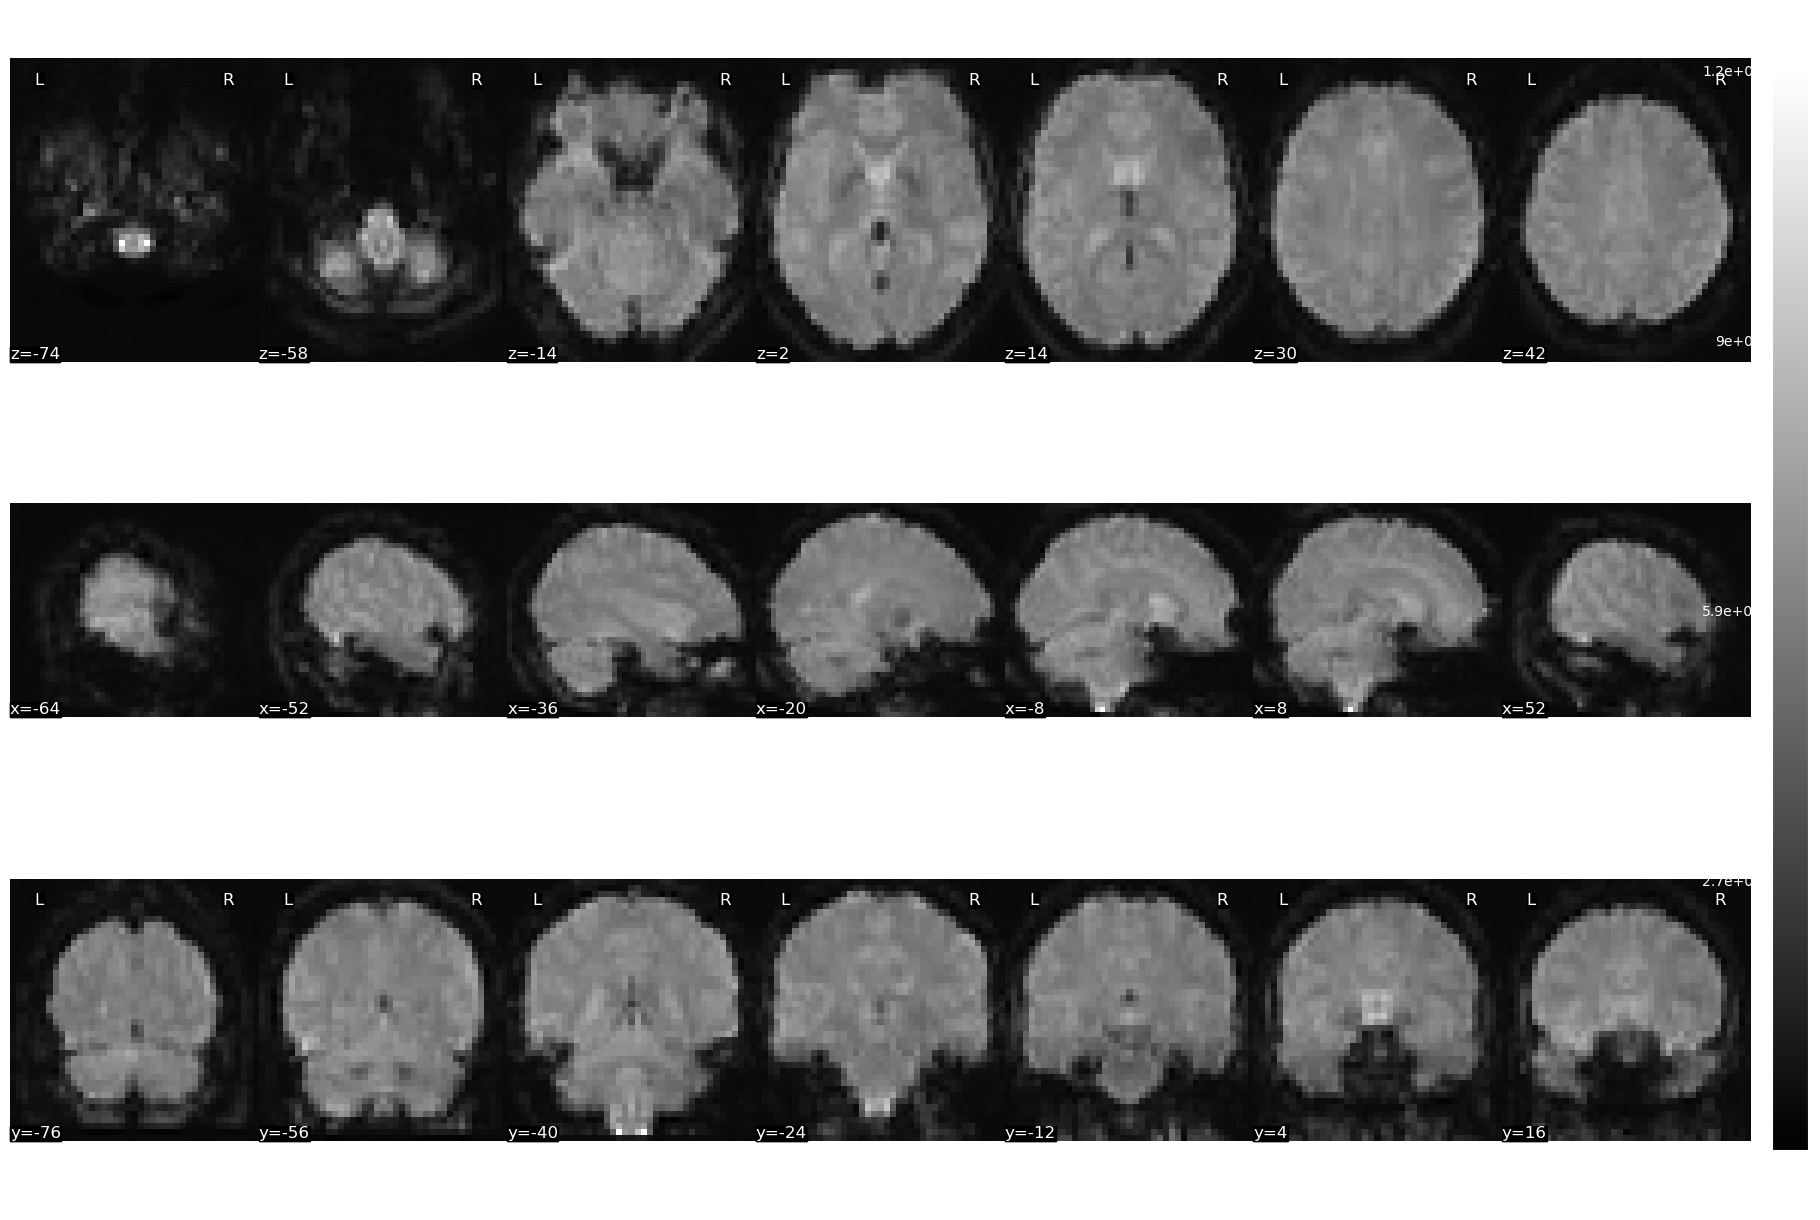

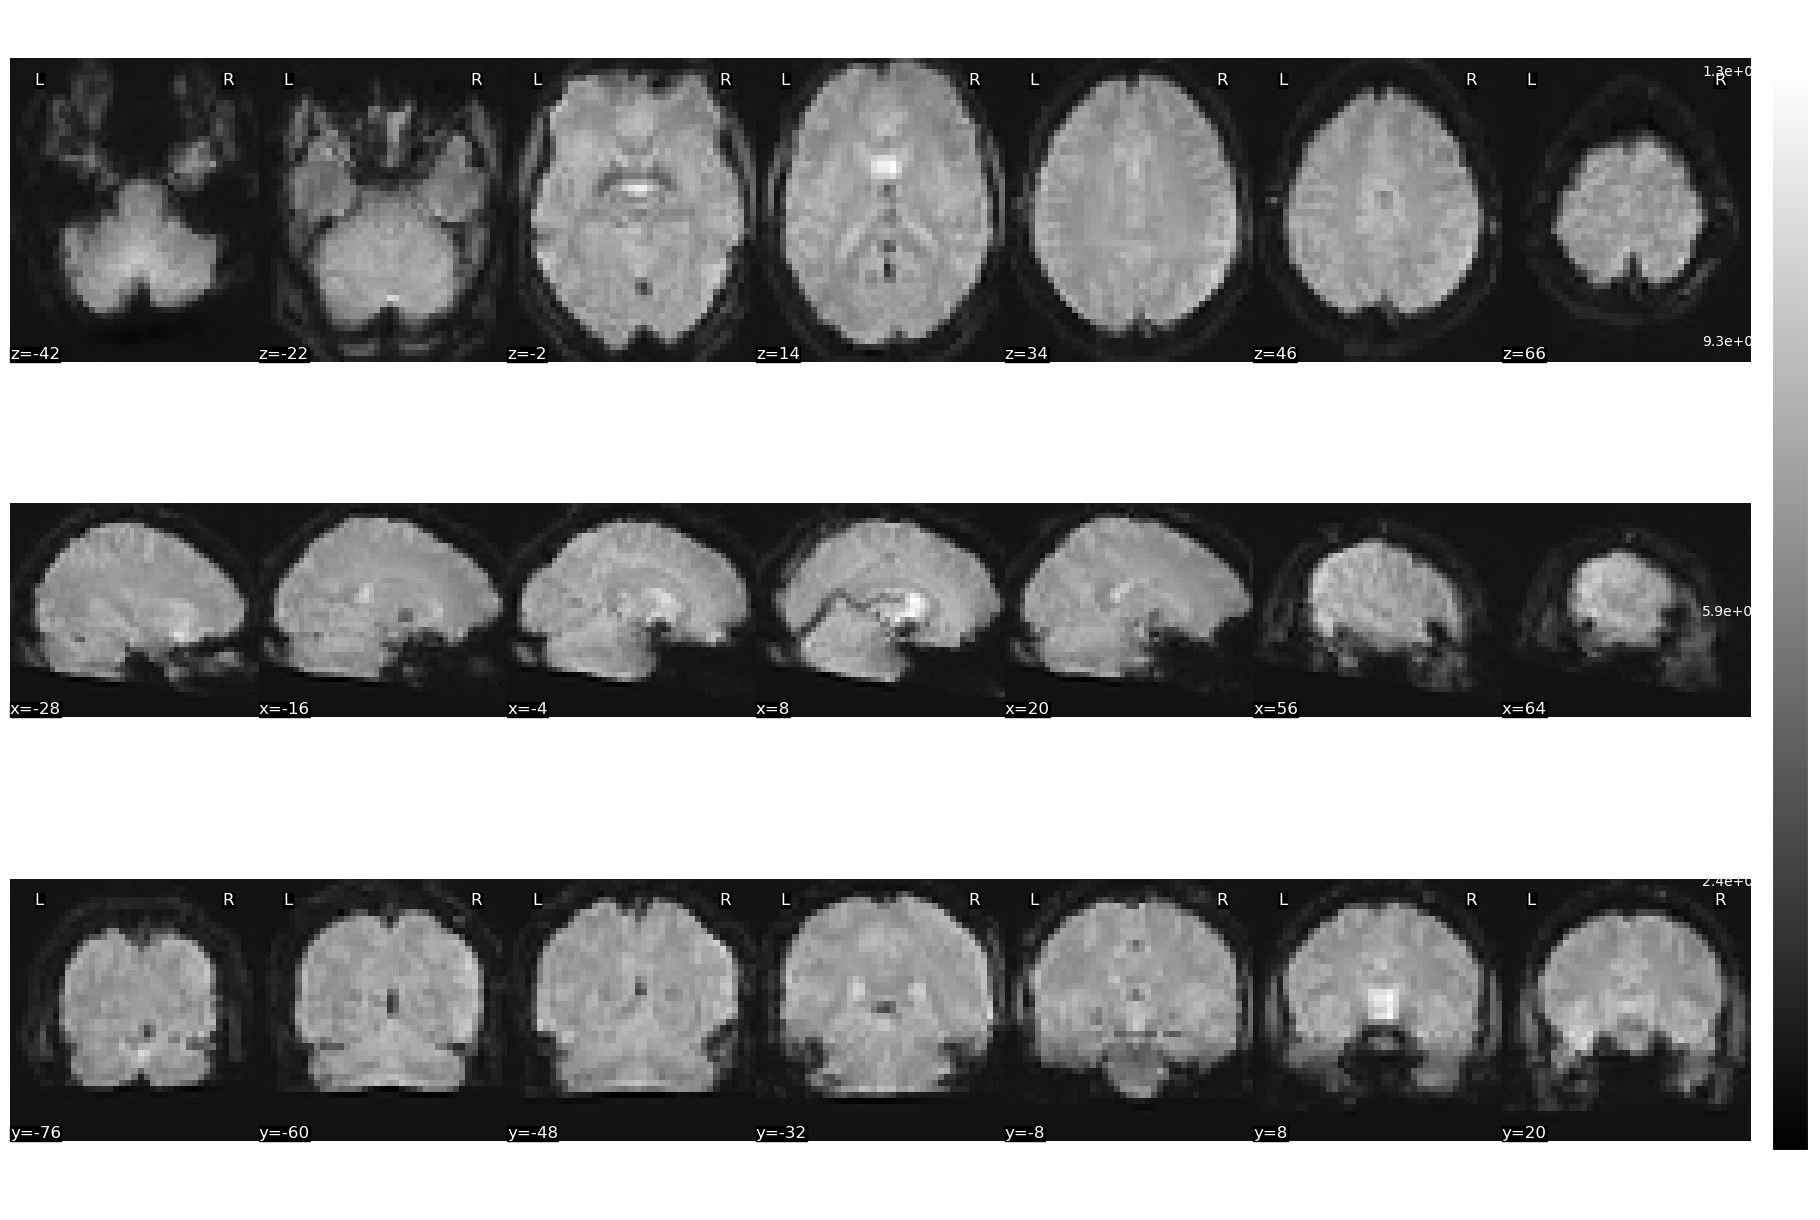

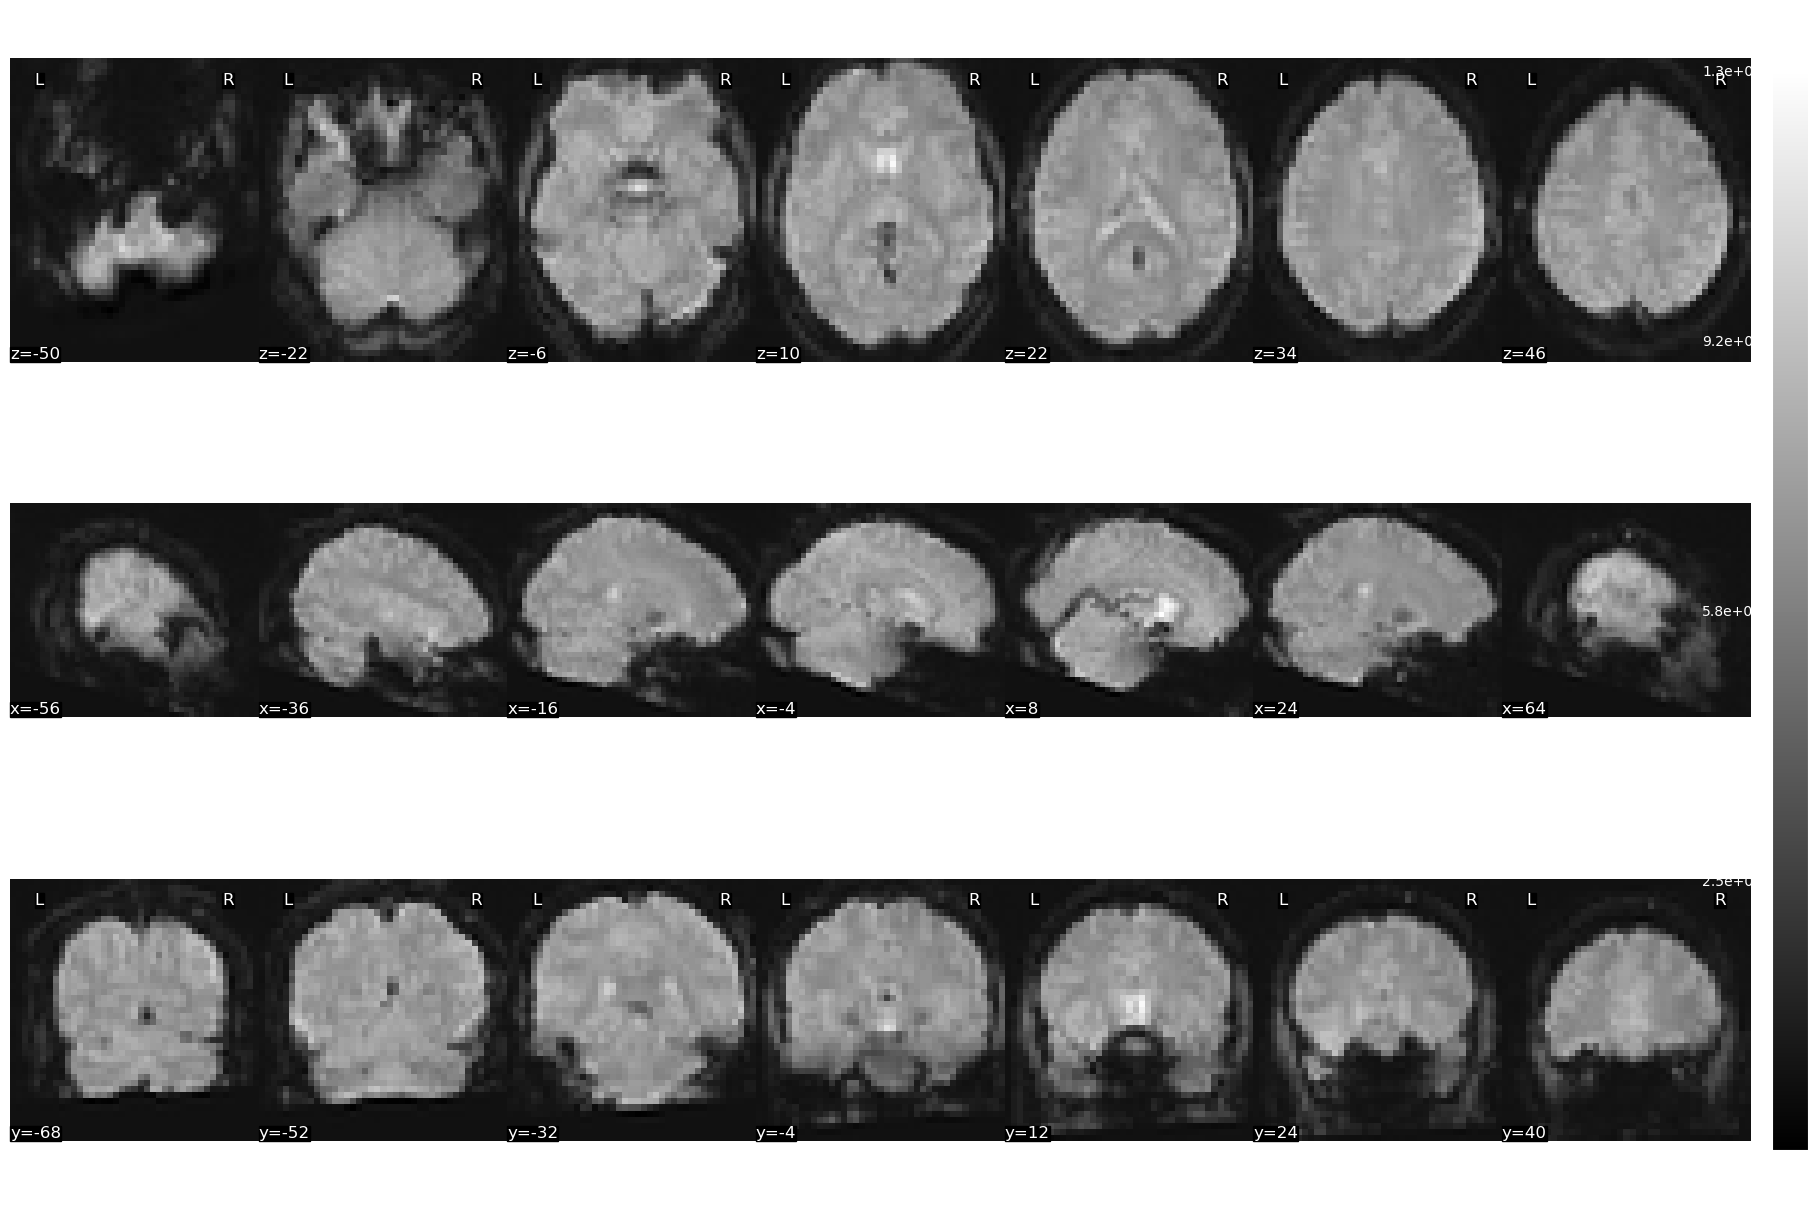

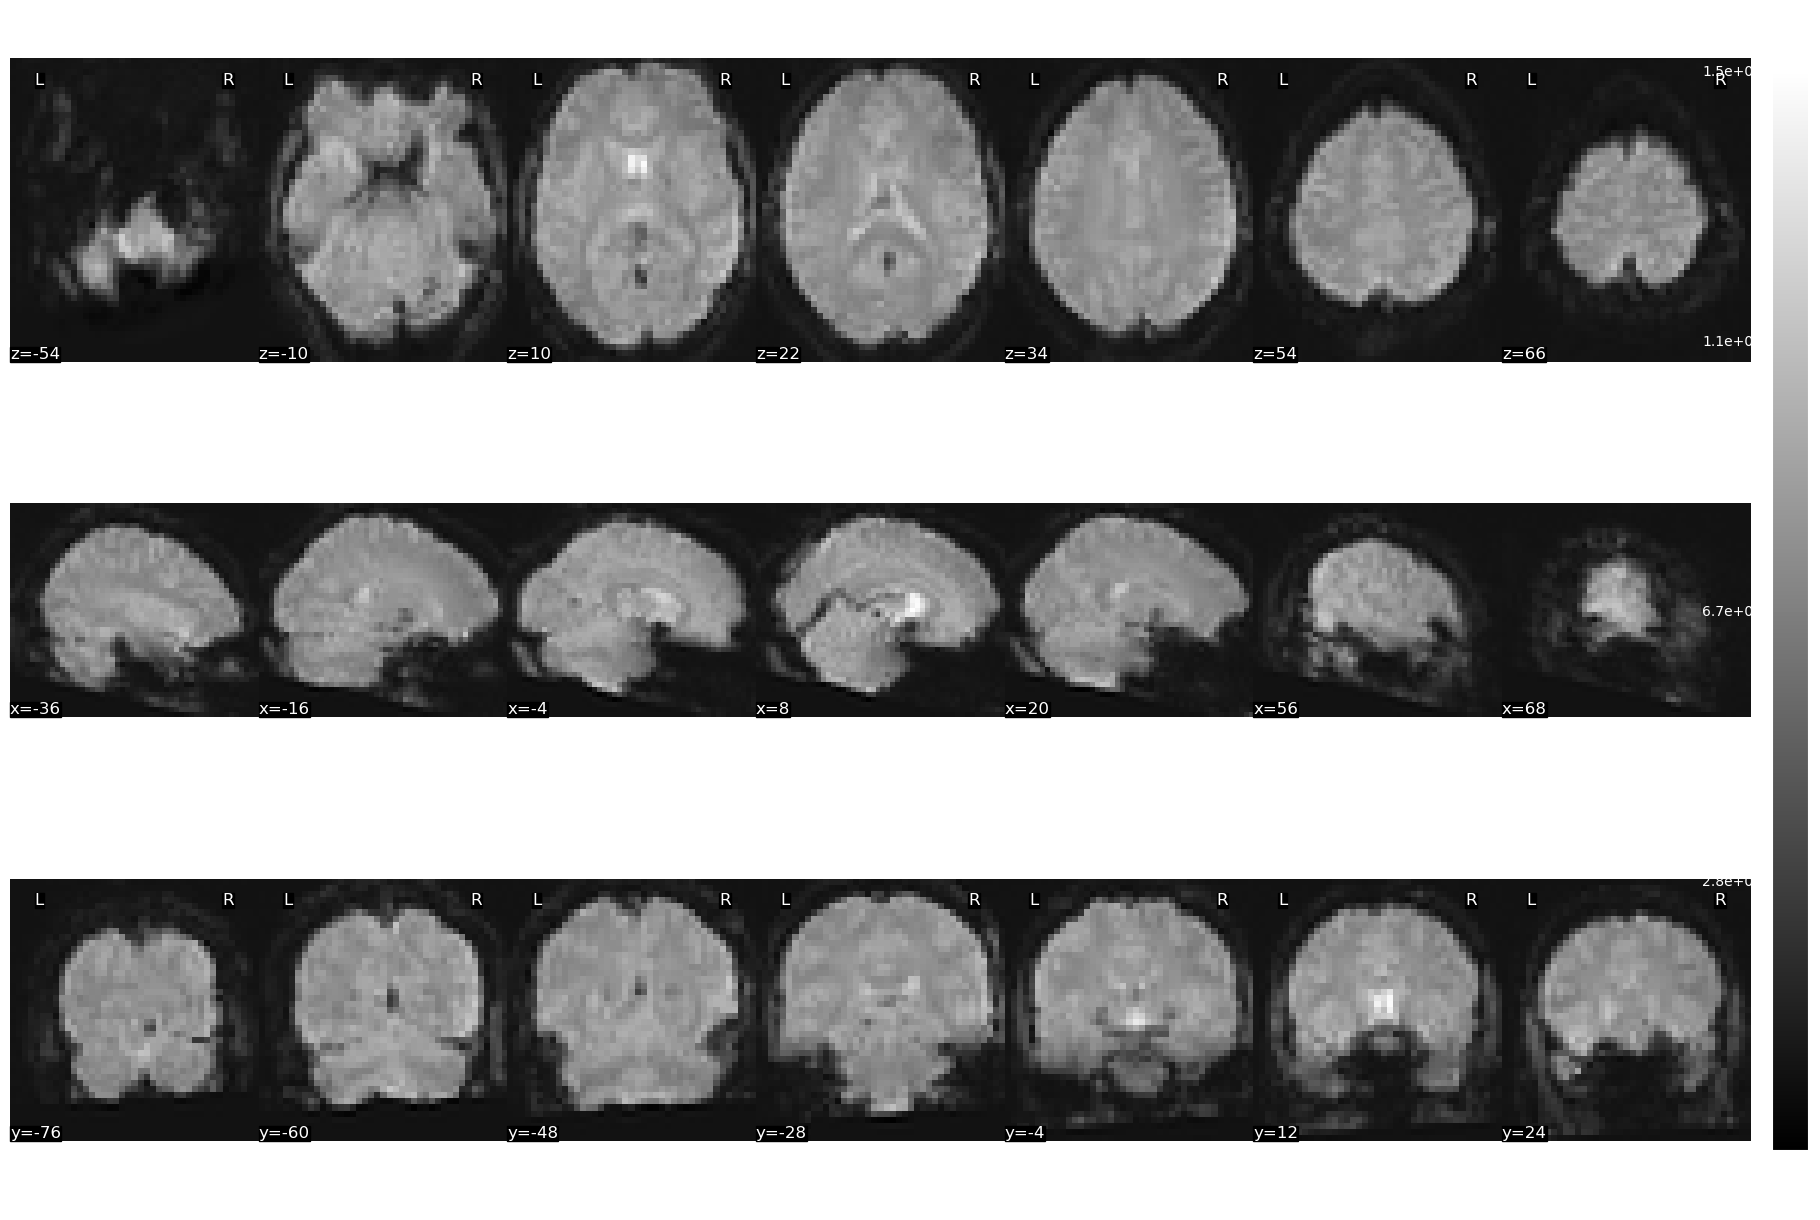

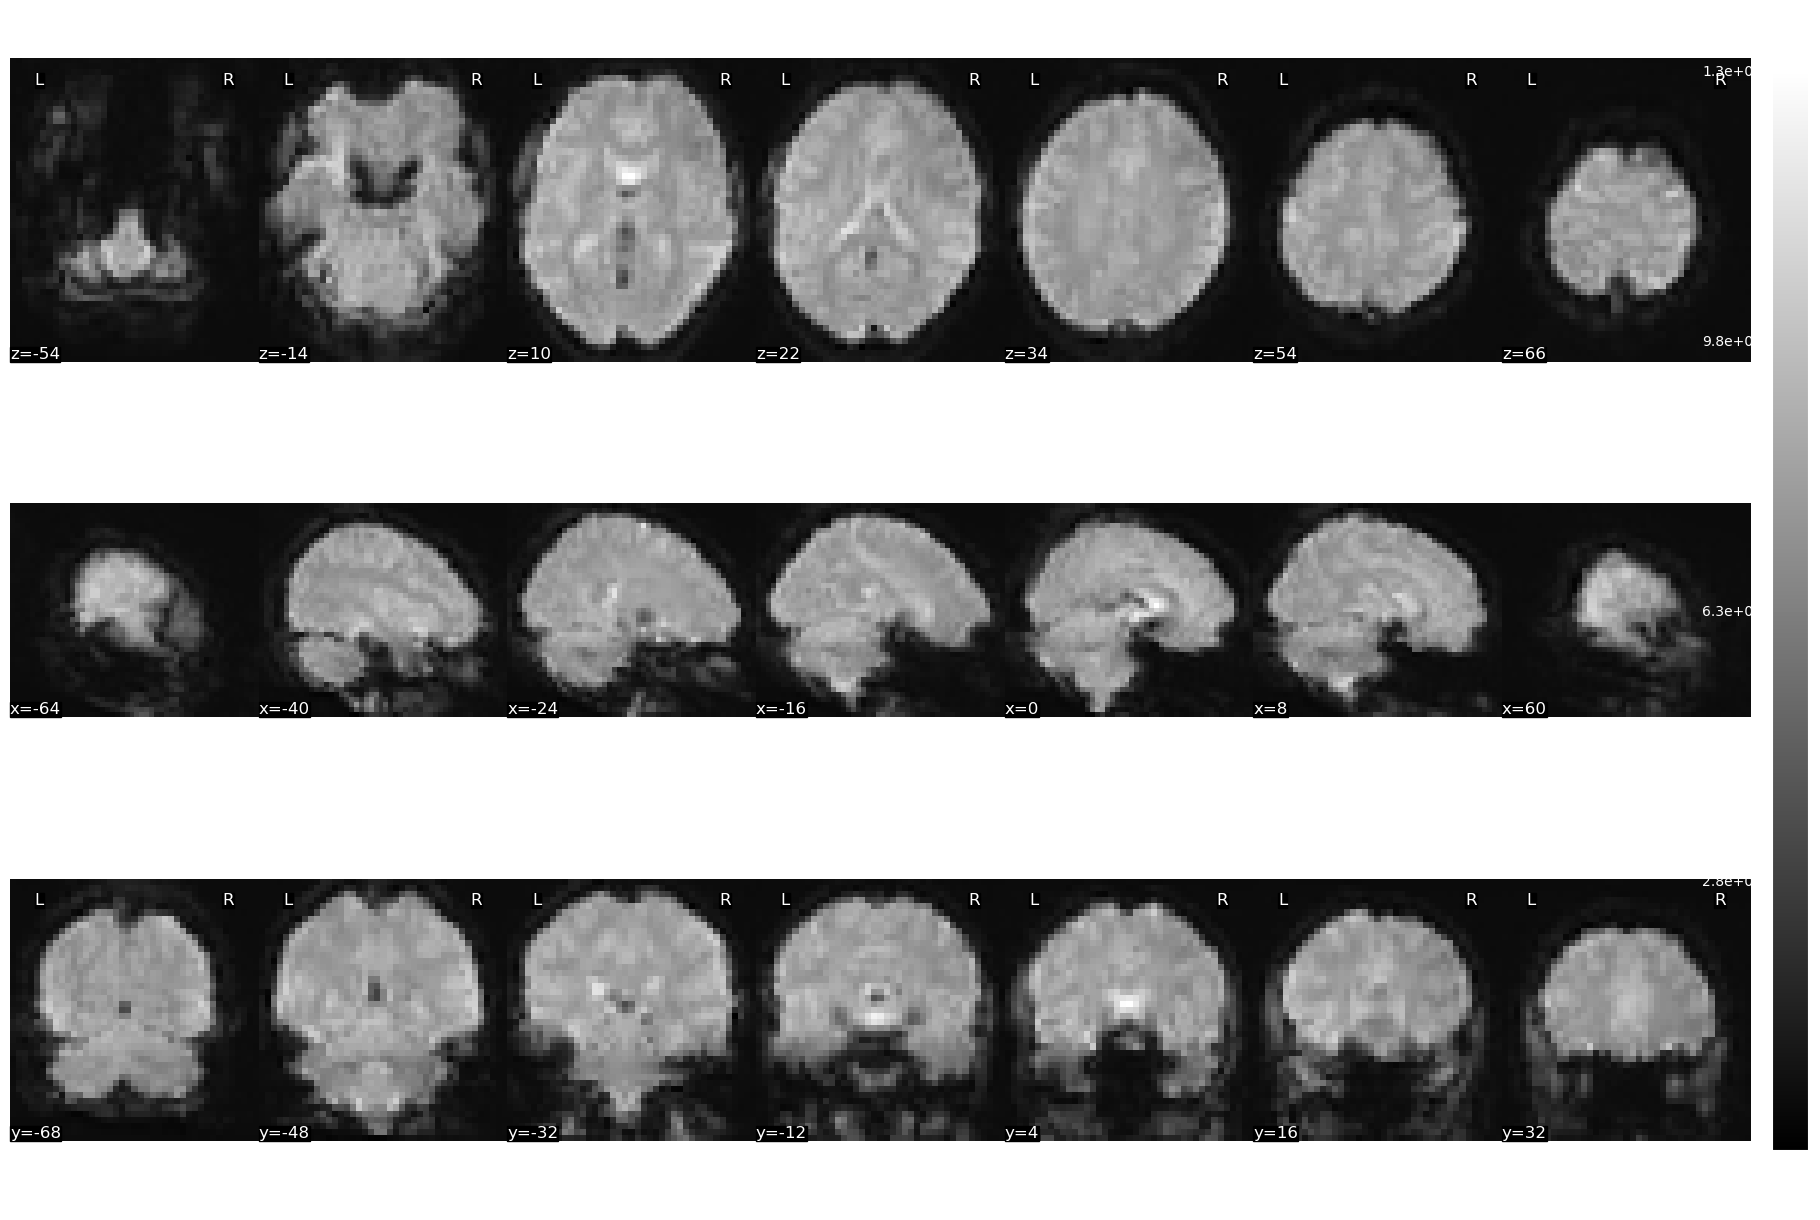

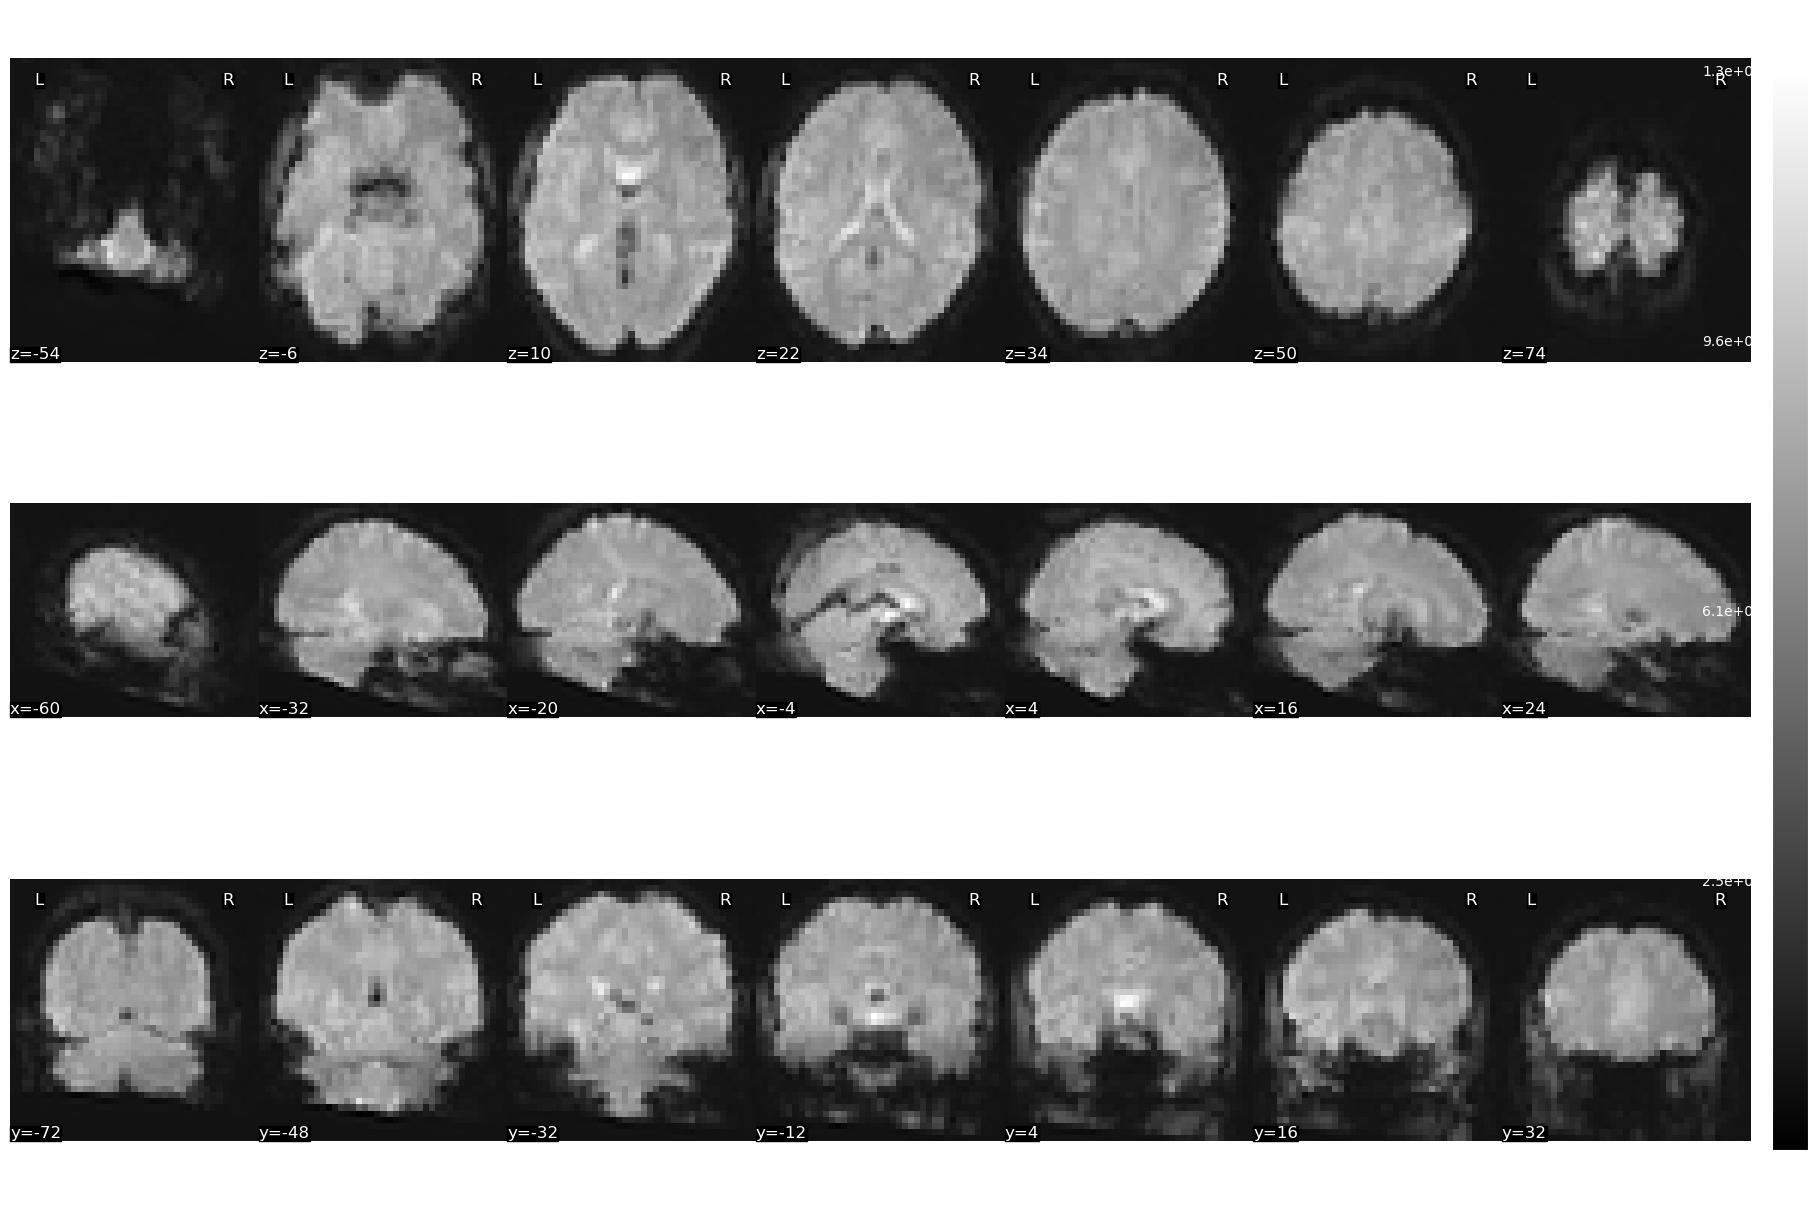

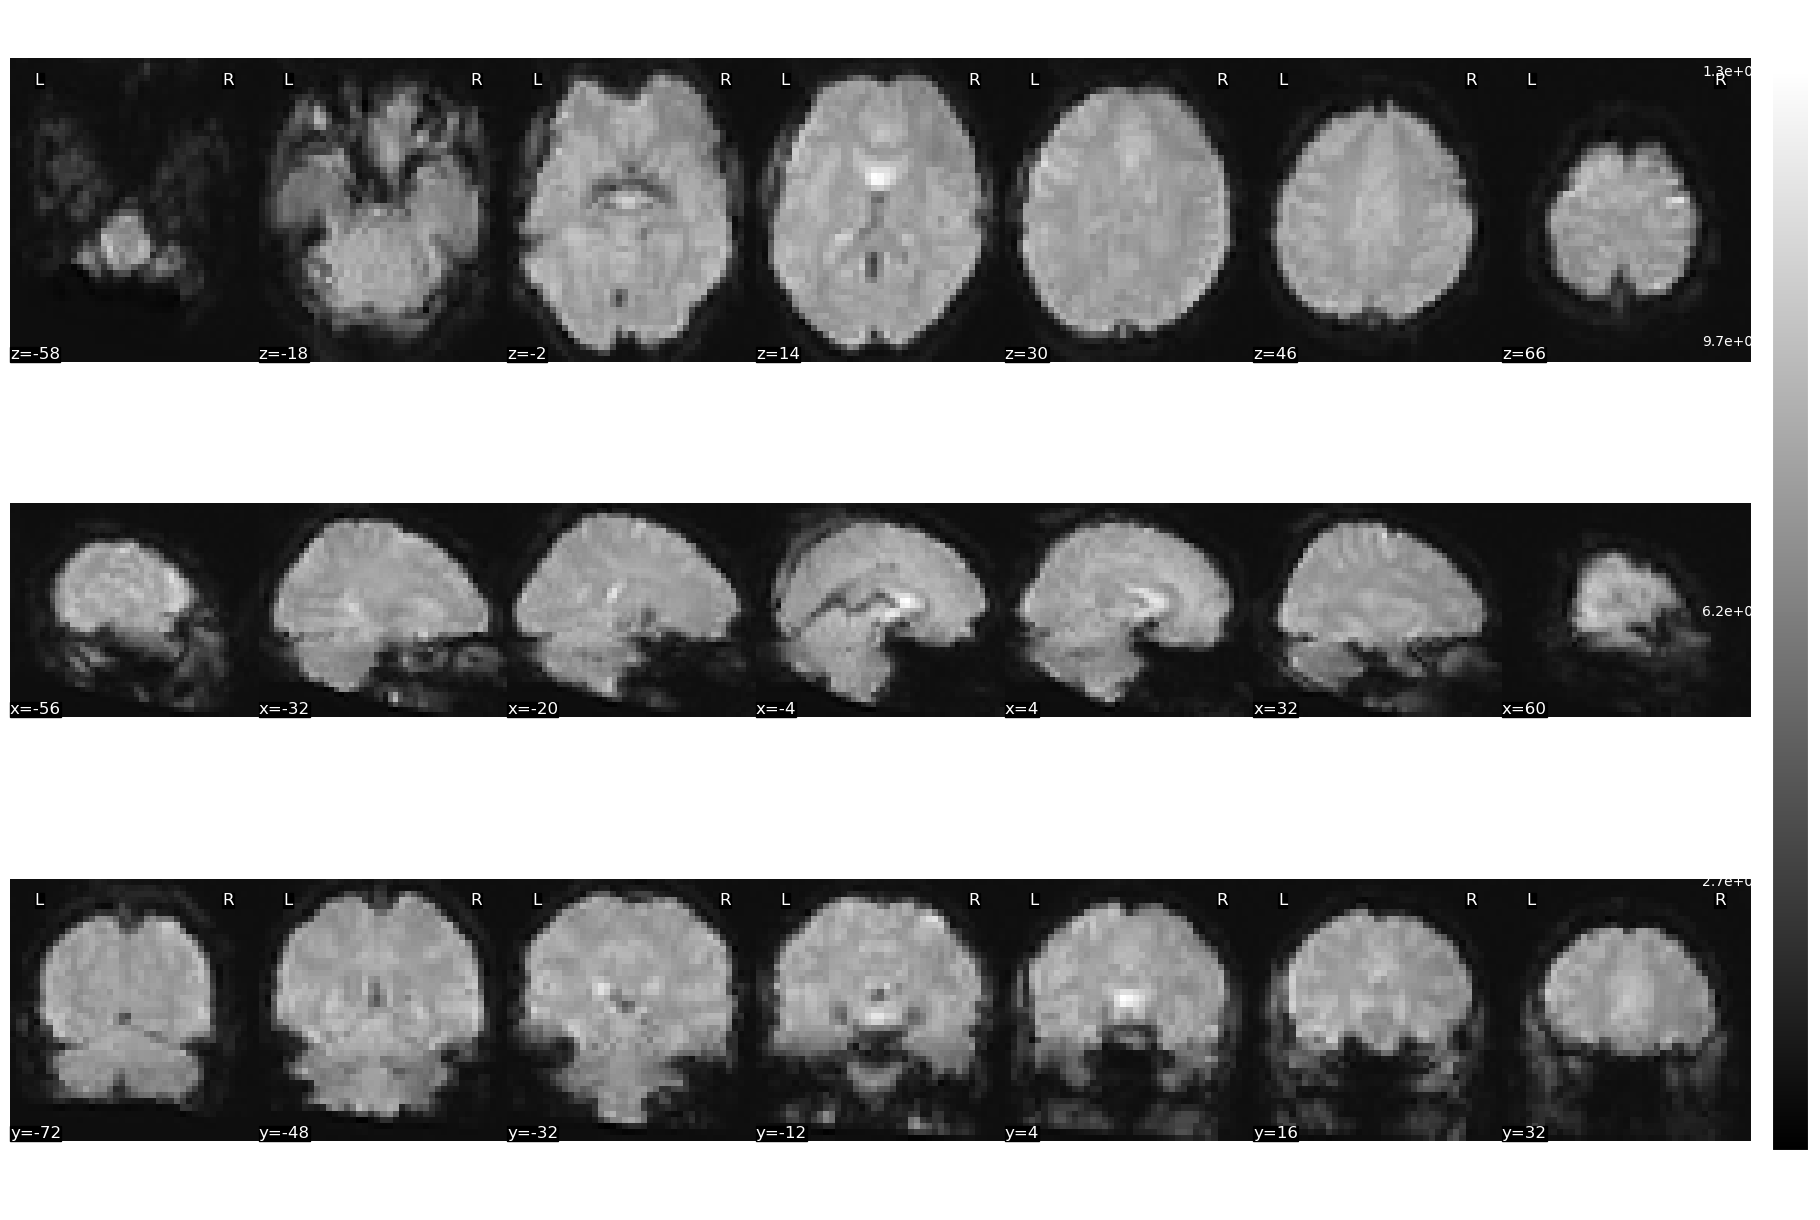

In [40]:
for i in range(len(bold_vis_check_files)):
    bold_img_name = "_".join(bold_vis_check_files[i].split('/')[-1].split("_")[:2])
    fig = plt.figure(num=bold_img_name, figsize=(18,12))
    b_img = nib.load(bold_vis_check_files[i])
    plot_epi(epi_img=b_img.slicer[:,:,:,75], display_mode='mosaic', figure=fig)

A perusal through the bold images show us that things are roughly as we expect them to be.  There are mild distortions here and there, but we will ignore them for now.  Also note that these images don't show skull stripping.  FMRIPrep gives us brain masks we can use for that later.  Let's continue setting up the rest of what we need, such as finding an atlas that helps us identify the FEF.  A paper by Reteig et al. 2018 confirms the average center of the FEF as [31.5, -1.8, 51.6].  Ideally, we'd get to pick BA8, the Brodmann Area best associated with the FEF, but the atlases available through siibra do not allow it.  Other ways include estimating from the T1-weighted image.  If the rough estimate doesn't work out, I'll go through the trouble but it is currently unnecessary.  Now that we have a spot to go with, let's create a large spherical ROI.  This way, we can only gain noise and not reduce info!

In [5]:
# Create ROI center
ROI_center = (32, -2, 52) 


# mni_atlas = nib.load(nil.datasets.fetch_icbm152_2009().t1)

In [4]:
# Find the brain mask.  Yes, there are better ways to do it.  Yes, this is pure laziness on my part.
bmask_suff = bold_suff.split("_")[:-2]
bmask_suff.append("desc-brain_mask.nii.gz")
bmask_suff = "_".join(bmask_suff)

In [5]:
# Brain mask
bmask_img_name = subj_pref + "01" + "_" + sess_pref + "01" + bmask_suff
path = data_path + subj_pref + "01" + "/" + sess_pref + "01" + "/func/" +  bmask_img_name
brain_mask = nib.load(path)

In [6]:
# Let's just get the skull-stripped brain
bold_img_name = subj_pref + "01" + "_" + sess_pref + "01" 
bold_path = data_path + subj_pref + "01" + "/" + sess_pref + "01" + "/func/" +  bold_img_name + bold_suff
preproc_bold_w_skull = nib.load(bold_path)
skull_stripped = preproc_bold_w_skull.get_fdata() * brain_mask.get_fdata()[..., None]
preproc_func = nib.Nifti1Image(skull_stripped, preproc_bold_w_skull.affine, preproc_bold_w_skull.header)
nib.save(preproc_func, "./" + bold_img_name + "_task-memoryscenes_space-MNI152NLin2009cAsym_desc-skull_stripped_preproc_bold.nii.gz")

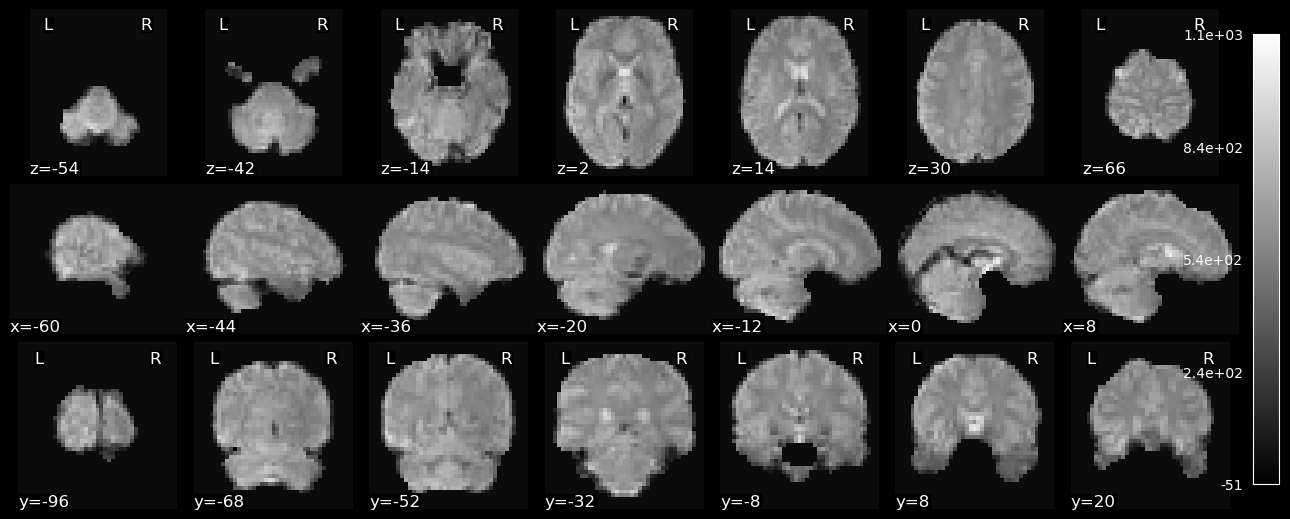

In [11]:
plot_epi(epi_img=preproc_func.slicer[:,:,:,75], display_mode='mosaic')

In [180]:
# Sphere mask creation
# Turns out this is more annoying than expected, so let's just do math. Because we'll be needing this again, let's make a function.

def ROI_sphere(nib_img, MNI_coord, radius):
    """
    Returns an ROI sphere maskfor a 3d or 4d volume given the center and radius.

    Parameters:
    nib_img (nibabel.nifti1.Nifti1Image): The 3d (T1) or 4d (T2*) scan of a human brain loaded using nibabel's load function.
    MNI_coord (tuple of 3 integers): The x, y, z coordinates for the center of the sphere in MNI space.
    radius (float or int): The radius of the sphere in millimeters.

    Returns:
    mask_img (nibabel.nifti1.Nifti1Image): A mask ready to be used with the input image.
    """

    # First, we need to change the center of our ROI from MNI space to voxel space.
    inverse_aff = np.linalg.inv(nib_img.affine)
    MNI_homo = [c for c in MNI_coord]
    MNI_homo.append(1)
    vox_center_homo = inverse_aff @ MNI_homo
    i,j,k = vox_center_homo[:3].astype(int)

    # We also need an index grid.  Now, we don't know whether we will get 3d or 4d data, 
    # so we'll have to just take the first three dimensions.
    (coordi, coordj, coordk) = np.indices(nib_img.shape[:3])

    # Now we need to transfer the radius into voxel space as well.  For this, we need the 
    # spatial resolution of the scan; basically, a vox = ? mm
    dimx,dimy,dimz = nib_img.header.get_zooms()[:3]
    assert dimx==dimy and dimy==dimz, "The dimensions of the voxel are not the same size."
    vox_rad = (radius + (dimx/2))//dimx # I could've rounded and converted to int but I think this might be slightly more efficient.
    
    # Now, we create the cube in which our sphere is circumscribed. We are naming the start
    # and stop coordinates using 0 and 1 respectively because, well, it's short and makes sense.
    i0, i1 = int(i-vox_rad), int(i+vox_rad)
    j0, j1 = int(j-vox_rad), int(j+vox_rad)
    k0, k1 = int(k-vox_rad), int(k+vox_rad)

    # We can now use these indices to subset our grid
    bbi = coordi[i0:i1, j0:j1, k0:k1]
    bbj = coordj[i0:i1, j0:j1, k0:k1]
    bbk = coordk[i0:i1, j0:j1, k0:k1]

    # Now let's get the euclidean distances between the center and all other voxels
    eu_dist_bb = np.sqrt(((bbi-i)**2)+((bbj-j)**2)+((bbk-k)**2))
    maskbb = (eu_dist_bb <= vox_rad)

    # We have the sphere!  But it's in the bounding box.  Let's move it to where it's supposed to be.
    mask_img_data = np.zeros(nib_img.shape[:3], dtype=float)
    mask_img_data[i0:i1, j0:j1, k0:k1] = maskbb
    
    # Now, after all that, we return the mask as a 3d nib image.
    mask_img = nib.Nifti1Image(mask_img_data, nib_img.affine)

    return mask_img
    

In [124]:
# An ROI mask for the FEF
sphere_mask = ROI_sphere(preproc_func, ROI_center, 12)

In [ ]:
confdf = pd.read_csv(data_path + subj_pref + "01" + "/" + sess_pref + "01" + "/func/" + bold_img_name + "_task-memoryscenes_desc-confounds_timeseries.tsv", header=0, sep="\t")
confdf = confdf.fillna(0)

In [125]:
FEF_mask = nil.maskers.NiftiMasker(sphere_mask, standardize='zscore_sample', detrend=True, low_pass=0.1, high_pass=0.01, t_r=2.2)

In [126]:
# Apply mask and extract time series
FEF_ts = FEF_mask.fit_transform(preproc_func, confounds=confdf)

In [127]:
FEF_ts.shape

(121, 120)

Let's save everything now.

In [130]:
nib.save(sphere_mask, "./Sphere_Mask.nii")
np.save("./FEF_ts.npy", FEF_ts)

Now we have a timeseries dataset that is of the shape time x voxels. We are done with the first part of isolating and shaping the data of interest.

---

Now that we have data in the form of an ndarray, we can now go ahead and create the dataset we need for our analysis.  We are going to take our time series and chop it up into "indoor" and "outdoor" according to the image presentation.

In [6]:
FEF_ts = np.load("./FEF_ts.npy")

In [134]:
fefdf = pd.DataFrame(data=FEF_ts, index=np.arange(FEF_ts.shape[0])*2.2, columns=["v"+str(i) for i in range(FEF_ts.shape[1])])

In [136]:
fefdf.tail()

,v0,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v110,v111,v112,v113,v114,v115,v116,v117,v118,v119
255.2,0.035912,0.035912,-0.035912,-0.035912,0.035912,0.035912,0.035912,-0.035912,-0.035912,0.035912,...,-0.035912,-0.035912,-0.035912,0.035912,0.035912,-0.035912,0.035912,0.035912,0.035912,0.035912
257.4,-0.031444,-0.031444,0.031444,0.031444,-0.031444,-0.031444,-0.031444,0.031444,0.031444,-0.031444,...,0.031444,0.031444,0.031444,-0.031444,-0.031444,0.031444,-0.031444,-0.031444,-0.031444,-0.031444
259.6,0.023140,0.023140,-0.023140,-0.023140,0.023140,0.023140,0.023140,-0.023140,-0.023140,0.023140,...,-0.023140,-0.023140,-0.023140,0.023140,0.023140,-0.023140,0.023140,0.023140,0.023140,0.023140
261.8,-0.012229,-0.012229,0.012229,0.012229,-0.012229,-0.012229,-0.012229,0.012229,0.012229,-0.012229,...,0.012229,0.012229,0.012229,-0.012229,-0.012229,0.012229,-0.012229,-0.012229,-0.012229,-0.012229
264.0,0.003158,0.003158,-0.003158,-0.003158,0.003158,0.003158,0.003158,-0.003158,-0.003158,0.003158,...,-0.003158,-0.003158,-0.003158,0.003158,0.003158,-0.003158,0.003158,0.003158,0.003158,0.003158


In [ ]:
from nilearn.glm.first_level import make_first_level_design_matrix

In [150]:
eventsdf = pd.read_csv("../ds000224/sub-MSC01/ses-func01/func/sub-MSC01_ses-func01_task-memoryscenes_events.tsv", sep='\t')
eventsdf.head()

,onset,duration,trial_type,response_time,correct
0,11.0,2.2,indoor_corr_1,1.126,corr
1,13.2,2.2,indoor_corr_1,1.199,corr
2,15.4,2.2,indoor_corr_1,1.031,corr
3,19.8,2.2,outdoor_corr_1,1.073,corr
4,22.0,2.2,outdoor_corr_1,0.797,corr


In [154]:
des_mat = make_first_level_design_matrix(fefdf.index.to_numpy(), eventsdf, hrf_model='spm')

/tmp/ipykernel_643/3255061736.py:1: UserWarning: The following unexpected columns in events data will be ignored: correct, response_time
  des_mat = make_first_level_design_matrix(fefdf.index.to_numpy(), eventsdf, hrf_model='spm')


In [155]:
des_mat.head()

,err,indoor_corr_1,indoor_corr_2,indoor_corr_3,outdoor_corr_1,outdoor_corr_2,outdoor_corr_3,drift_1,drift_2,drift_3,drift_4,drift_5,constant
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.128554,0.128522,0.128467,0.128392,0.128294,1.0
2.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.128467,0.128175,0.127688,0.127008,0.126135,1.0
4.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.128294,0.127483,0.126135,0.124256,0.121853,1.0
6.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.128034,0.126447,0.123817,0.120165,0.115521,1.0
8.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.127688,0.125071,0.120748,0.114779,0.107244,1.0


<Axes: label='conditions', ylabel='scan number'>

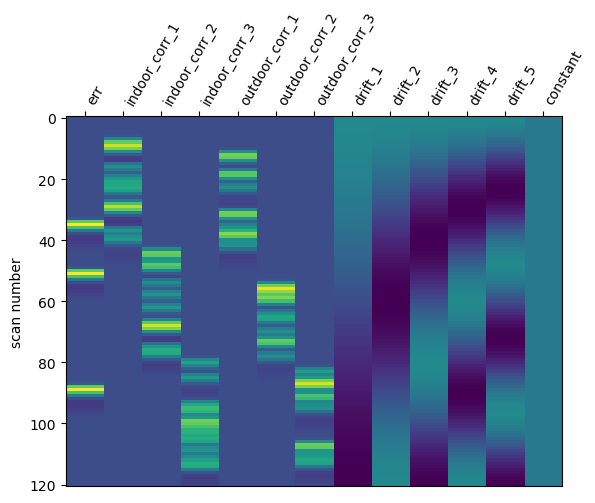

In [157]:
fig, ax = plt.subplots(1,1)
nil.plotting.plot_design_matrix(des_mat, axes=ax)

In [162]:
eventsdf['trial_type'][(eventsdf['trial_type']=='indoor_corr_2') | (eventsdf['trial_type']=='outdoor_corr_2')]

24     indoor_corr_2
25     indoor_corr_2
26     indoor_corr_2
27     indoor_corr_2
29     indoor_corr_2
30    outdoor_corr_2
31    outdoor_corr_2
32    outdoor_corr_2
33     indoor_corr_2
34    outdoor_corr_2
35    outdoor_corr_2
36     indoor_corr_2
37    outdoor_corr_2
38    outdoor_corr_2
39     indoor_corr_2
40     indoor_corr_2
41     indoor_corr_2
42    outdoor_corr_2
43    outdoor_corr_2
44    outdoor_corr_2
45     indoor_corr_2
46     indoor_corr_2
47    outdoor_corr_2
Name: trial_type, dtype: object

I don't see a reason to differentiate between whatever *corr_\d means.  So, let's just have indoor, outdoor, and error.

In [166]:
eventsdf['trial_type'] = eventsdf['trial_type'].map(lambda x: x.split("_")[0])

In [168]:
eventsdf.head()

,onset,duration,trial_type,response_time,correct
0,11.0,2.2,indoor,1.126,corr
1,13.2,2.2,indoor,1.199,corr
2,15.4,2.2,indoor,1.031,corr
3,19.8,2.2,outdoor,1.073,corr
4,22.0,2.2,outdoor,0.797,corr


Let's try again!

In [169]:
des_mat = make_first_level_design_matrix(fefdf.index.to_numpy(), eventsdf, hrf_model='spm')

/tmp/ipykernel_643/3255061736.py:1: UserWarning: The following unexpected columns in events data will be ignored: correct, response_time
  des_mat = make_first_level_design_matrix(fefdf.index.to_numpy(), eventsdf, hrf_model='spm')


<Axes: label='conditions', ylabel='scan number'>

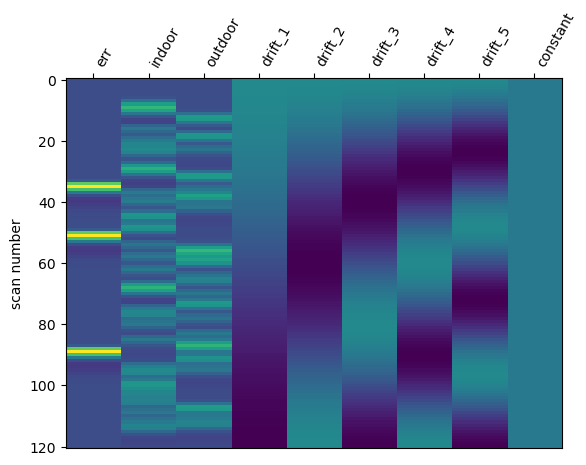

In [170]:
fig, ax = plt.subplots(1,1)
nil.plotting.plot_design_matrix(des_mat, axes=ax)

In [172]:
des_mat.head(20)

,err,indoor,outdoor,drift_1,drift_2,drift_3,drift_4,drift_5,constant
0.0,0.0,0.000000,0.000000,0.128554,0.128522,0.128467,0.128392,0.128294,1.0
2.2,0.0,0.000000,0.000000,0.128467,0.128175,0.127688,0.127008,0.126135,1.0
4.4,0.0,0.000000,0.000000,0.128294,0.127483,0.126135,0.124256,0.121853,1.0
6.6,0.0,0.000000,0.000000,0.128034,0.126447,0.123817,0.120165,0.115521,1.0
8.8,0.0,0.000000,0.000000,0.127688,0.125071,0.120748,0.114779,0.107244,1.0
11.0,0.0,0.000000,0.000000,0.127256,0.123357,0.116947,0.108156,0.097163,1.0
13.2,0.0,0.027429,0.000000,0.126738,0.121311,0.112436,0.100367,0.085446,1.0
15.4,0.0,0.327915,0.000000,0.126135,0.118938,0.107244,0.091497,0.072292,1.0
17.6,0.0,0.767950,0.000000,0.125447,0.116244,0.101402,0.081641,0.057921,1.0
19.8,0.0,1.012536,0.000000,0.124674,0.113236,0.094944,0.070906,0.042575,1.0


Let's take a look at the line plots for our regressors.

Text(0.5, 0, 'Time (s)')

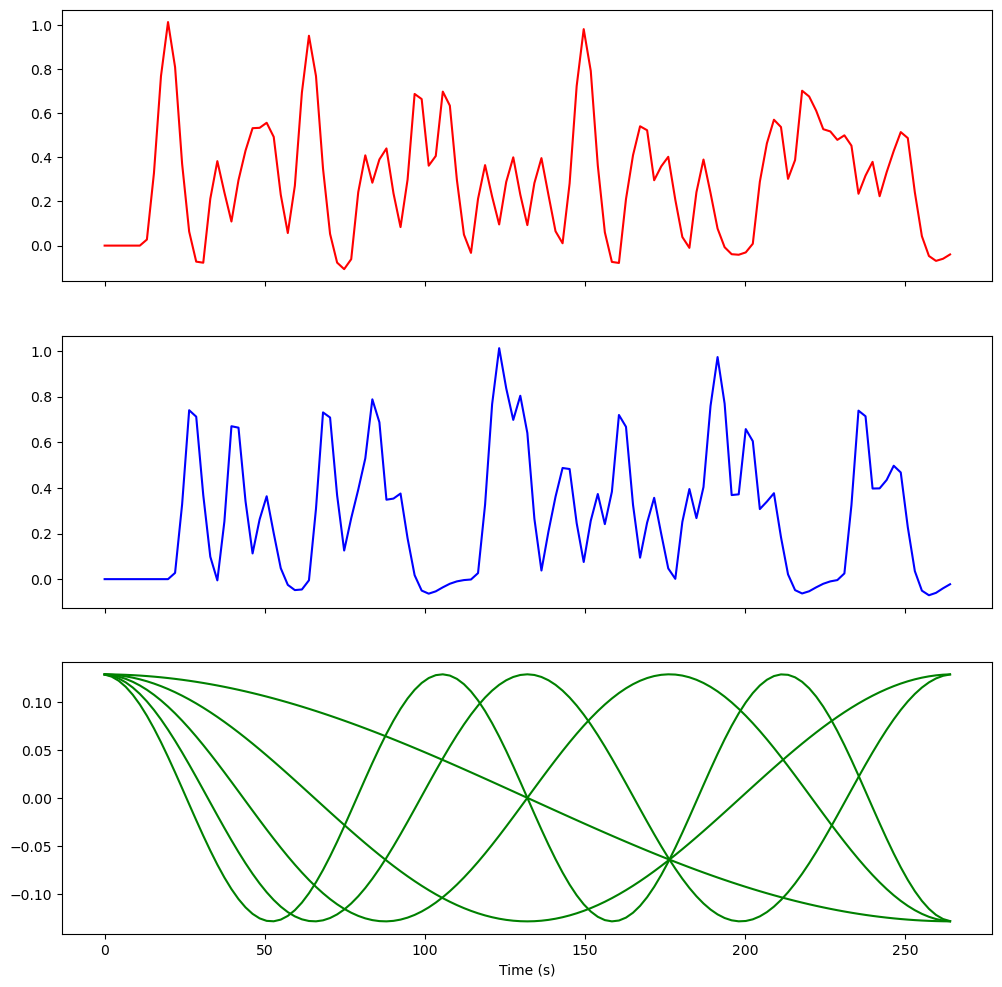

In [177]:
fig, ax = plt.subplots(3,1, figsize=(12,12), sharex=True)
ax[0].plot(des_mat['indoor'], c='r')
ax[1].plot(des_mat['outdoor'], c='b')
ax[2].plot(des_mat['drift_1'], c='g')
ax[2].plot(des_mat['drift_2'], c='g')
ax[2].plot(des_mat['drift_3'], c='g')
ax[2].plot(des_mat['drift_4'], c='g')
ax[2].plot(des_mat['drift_5'], c='g')
ax[2].set_xlabel("Time (s)")

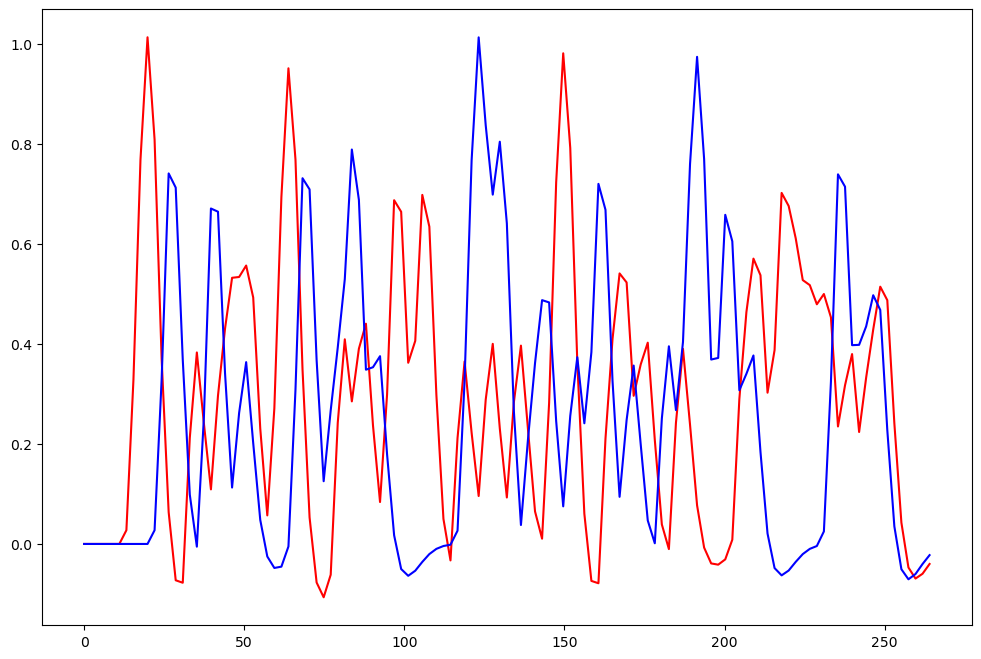

In [179]:
fig, ax = plt.subplots(1,1, figsize=(12,8))
ax.plot(des_mat['indoor'], c='r')
ax.plot(des_mat['outdoor'], c='b')

Much overlap.  Let's go check out all the other event files.

In [38]:
def get_events_file(parent_dir, subj, run, task):
    """
    Takes information about the scan and returns the 4d data with its design matrix and event data.
    """
    # Using the input, let's first create the paths to our events file, preprocessed brain, and brain mask.
    f_e = os.path.join("..", "ds000224", subj, run, 'func', "_".join([subj, run, task, "events.tsv"])) 
    f_b = os.path.join(parent_dir, subj, run, 'func', "_".join([subj, run, task, "space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz"]))
    f_m = os.path.join(parent_dir, subj, run, 'func', "_".join([subj, run, task, "space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz"]))

    if os.path.isfile(f_e):

        # If the events file exists, so should the others.  Although it's more robust to actually check for this, 
        # I know for a fact this is the case with this particular dataset.
        preproc_bold_w_skull = nib.load(f_b)
        b_mask = nib.load(f_m)
        skull_stripped = preproc_bold_w_skull.get_fdata() * b_mask.get_fdata()[..., None]
        preproc_func = nib.Nifti1Image(skull_stripped, preproc_bold_w_skull.affine, preproc_bold_w_skull.header)
        nib.save(preproc_func, os.path.join(parent_dir, subj, run, 'func', "_".join([subj, run, task, 
                                                                           "space-MNI152NLin2009cAsym", 
                                                                           "desc-skull_stripped_preproc_bold.nii.gz"])))
        t_r = preproc_bold_w_skull.header.get_zooms()[3]
        frames = preproc_bold_w_skull.shape[-1]
        
        edf = pd.read_csv(f_e, sep='\t')
        edf['trial_type'] = edf['trial_type'].map(lambda x: x.split("_")[0])
        edf = edf.drop(columns=["response_time", "correct"])

        # you generally need a theoretical justification for using a particular HRF, but we are going with spm because it's generally good
        des_mat = make_first_level_design_matrix(np.arange(frames)*t_r, edf, hrf_model='spm')
        des_mat.to_csv("../derivatives/" + os.path.join(subj, run, 'func', 
                                                                "_".join([subj, run, task, 
                                                                           "space-MNI152NLin2009cAsym", 
                                                                           "desc-designmatrix_hrf-spm.csv"])))
        return des_mat
    else:
        print(f"{subj} does not have BOLD data for {task} in {run}.")
        return None

In [26]:
data_path = "../derivatives/"
subj_pref = "sub-MSC"
sess_pref = "ses-func"
task_suff = "task-memoryscenes"
space_suff = "space-MNI152NLin2009cAsym"
desc_suff = "desc-preproc_bold"
# atlas = siibra.atlases.get('human')

In [27]:
dmat = get_events_file(data_path, subj_pref+str(0)+str(1), sess_pref+str(0)+str(1), task_suff)

Text(0.5, 0, 'Time (s)')

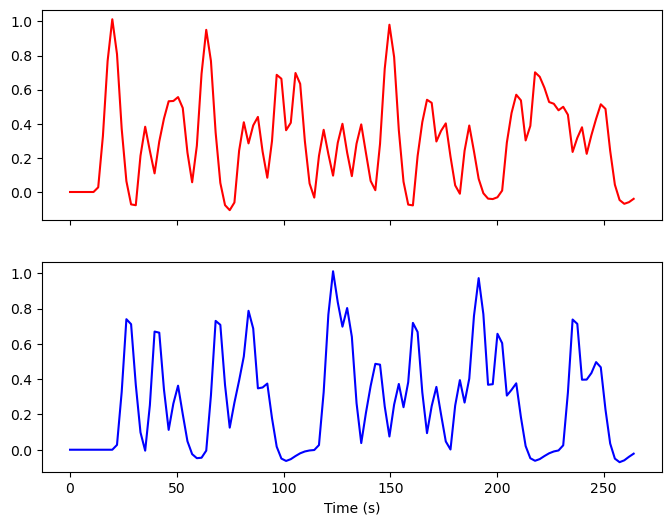

In [31]:
fig, ax = plt.subplots(2,1, figsize=(8,6), sharex=True)
ax[0].plot(dmat['indoor'], c='r')
ax[1].plot(dmat['outdoor'], c='b')
ax[1].set_xlabel("Time (s)")

In [48]:
if not os.path.exists("../plots"):
    os.mkdir("../plots")

for s in range(1,11):
    s = str(s)
    if len(s)==1:
        s = "0"+s
    for r in range(1,15):
        r = str(r)
        if len(r)==1:
            r = "0"+r
        dmat = get_events_file(data_path, subj_pref+s, sess_pref+r, task_suff)
        if str(type(dmat)) == "<class 'pandas.core.frame.DataFrame'>":
            fig, ax = plt.subplots(3,1, figsize=(10,8), sharex=True)
            sns.lineplot(data=dmat, x=dmat.index.to_numpy(), y="indoor", ax=ax[0])
            sns.lineplot(data=dmat, x=dmat.index.to_numpy(), y="outdoor", ax=ax[1])
            sns.lineplot(data=dmat, ax=ax[2])
            ax[2].set_xlabel("Time (s)")
            fig.savefig("../plots/"+"_".join([subj_pref+s, sess_pref+r, task_suff])+".png")
            plt.close(fig)

sub-MSC01 does not have BOLD data for task-memoryscenes in ses-func11.
sub-MSC01 does not have BOLD data for task-memoryscenes in ses-func12.
sub-MSC01 does not have BOLD data for task-memoryscenes in ses-func13.
sub-MSC01 does not have BOLD data for task-memoryscenes in ses-func14.
sub-MSC02 does not have BOLD data for task-memoryscenes in ses-func04.
sub-MSC02 does not have BOLD data for task-memoryscenes in ses-func08.
sub-MSC02 does not have BOLD data for task-memoryscenes in ses-func11.
sub-MSC02 does not have BOLD data for task-memoryscenes in ses-func12.
sub-MSC02 does not have BOLD data for task-memoryscenes in ses-func13.
sub-MSC02 does not have BOLD data for task-memoryscenes in ses-func14.
sub-MSC03 does not have BOLD data for task-memoryscenes in ses-func11.
sub-MSC03 does not have BOLD data for task-memoryscenes in ses-func12.
sub-MSC03 does not have BOLD data for task-memoryscenes in ses-func13.
sub-MSC03 does not have BOLD data for task-memoryscenes in ses-func14.
sub-MS

After looking at the plots, it seems like there might be two feasible ways to code the target variable.  One is taking 
whichever expected activity is higher by a certain amount at any given point in time.  The other is to treat each point 
in time as some percentage of one or the other category holding true.  Let's try the simplest method first.

---

Here, we will focus on testing a few different things:
* are all the voxels necessary to represent the FEF's activity?
* what is the best way to represent the target variable?
* do the data show any type of pattern from the get-go?
* what kind of model best fits the data?

In [2]:
data_path = "../derivatives/"
subj_pref = "sub-MSC01"
sess_pref = "ses-func01"
task_suff = "task-memoryscenes"
space_suff = "space-MNI152NLin2009cAsym"
desc_bold_suff = "desc-preproc_bold"
desc_hrf_suff = "desc-designmatrix_hrf-spm"
# atlas = siibra.atlases.get('human')

In [53]:
FEF_ts = np.load("./FEF_ts.npy")
idx = np.arange(FEF_ts.shape[0])*2.2
idx_str = [str(round(x,2)) for x in idx]

In [54]:
fefdf = pd.DataFrame(data=FEF_ts, index=idx_str, columns=["v"+str(i) for i in range(FEF_ts.shape[1])])

In [55]:
fefdf.head()

,v0,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v110,v111,v112,v113,v114,v115,v116,v117,v118,v119
0.0,-0.000118,-0.000118,0.000118,0.000118,-0.000118,-0.000118,-0.000118,0.000118,0.000118,-0.000118,...,0.000118,0.000118,0.000118,-0.000118,-0.000118,0.000118,-0.000118,-0.000118,-0.000118,-0.000118
2.2,0.000774,0.000774,-0.000774,-0.000774,0.000774,0.000774,0.000774,-0.000774,-0.000774,0.000774,...,-0.000774,-0.000774,-0.000774,0.000774,0.000774,-0.000774,0.000774,0.000774,0.000774,0.000774
4.4,-0.002754,-0.002754,0.002754,0.002754,-0.002754,-0.002754,-0.002754,0.002754,0.002754,-0.002754,...,0.002754,0.002754,0.002754,-0.002754,-0.002754,0.002754,-0.002754,-0.002754,-0.002754,-0.002754
6.6,0.007118,0.007118,-0.007118,-0.007118,0.007118,0.007118,0.007118,-0.007118,-0.007118,0.007118,...,-0.007118,-0.007118,-0.007118,0.007118,0.007118,-0.007118,0.007118,0.007118,0.007118,0.007118
8.8,-0.014985,-0.014985,0.014985,0.014985,-0.014985,-0.014985,-0.014985,0.014985,0.014985,-0.014985,...,0.014985,0.014985,0.014985,-0.014985,-0.014985,0.014985,-0.014985,-0.014985,-0.014985,-0.014985


In [3]:
edf = pd.read_csv("../derivatives/" + os.path.join(subj_pref, sess_pref, 'func', 
                                                   "_".join([subj_pref, sess_pref, task_suff, 
                                                             "space-MNI152NLin2009cAsym", 
                                                             "desc-designmatrix_hrf-spm.csv"])), header=0, index_col=0)
edf.head()

,err,indoor,outdoor,drift_1,drift_2,drift_3,drift_4,drift_5,constant
0.0,0.0,0.0,0.0,0.128554,0.128522,0.128467,0.128392,0.128294,1.0
2.2,0.0,0.0,0.0,0.128467,0.128175,0.127688,0.127008,0.126135,1.0
4.4,0.0,0.0,0.0,0.128294,0.127483,0.126135,0.124256,0.121853,1.0
6.6,0.0,0.0,0.0,0.128034,0.126447,0.123817,0.120165,0.115521,1.0
8.8,0.0,0.0,0.0,0.127688,0.125071,0.120748,0.114779,0.107244,1.0


In [4]:
edf.set_index(pd.Series([str(x) for x in np.round(edf.index.values,2)]), inplace=True)

In [7]:
edf['indoor_activity_higher'] = edf['indoor'] >= edf['outdoor']*1.35

In [8]:
edf[edf['indoor_activity_higher']==True].shape

(60, 10)

In [9]:
edf['indoor_activity_higher'] = edf['indoor'] - edf['outdoor']*1.35 >= 0.25

In [10]:
edf['outdoor_activity_higher'] = edf['outdoor'] - edf['indoor']*1.35 >= 0.25

In [12]:
edf.describe()

,err,indoor,outdoor,drift_1,drift_2,drift_3,drift_4,drift_5,constant
count,121.000000,121.000000,121.000000,1.210000e+02,1.210000e+02,1.210000e+02,1.210000e+02,1.210000e+02,121.0
mean,0.024795,0.297872,0.272892,-6.881548e-19,-4.128929e-18,4.817083e-18,-2.752619e-18,-9.175397e-19,1.0
std,0.093182,0.262408,0.283488,9.128709e-02,9.128709e-02,9.128709e-02,9.128709e-02,9.128709e-02,0.0
min,-0.039836,-0.106567,-0.070624,-1.285540e-01,-1.285649e-01,-1.285540e-01,-1.285215e-01,-1.285540e-01,1.0
25%,0.000000,0.057075,0.000000,-9.031710e-02,-9.149725e-02,-9.031710e-02,-8.912172e-02,-9.031710e-02,1.0
50%,0.000000,0.289423,0.252920,7.872328e-18,-1.668955e-03,-2.361698e-17,1.668955e-03,3.936164e-17,1.0
75%,0.000000,0.463155,0.397906,9.031710e-02,8.912172e-02,9.031710e-02,9.149725e-02,9.031710e-02,1.0
max,0.440436,1.012536,1.012372,1.285540e-01,1.285215e-01,1.285540e-01,1.285649e-01,1.285540e-01,1.0


In [61]:
edf.loc[:,'activity'] = ['nontask']*edf.shape[0]
edf.loc[edf['indoor_activity_higher']==True, 'activity'] = "indoor"
edf.loc[edf['outdoor_activity_higher']==True, 'activity'] = "outdoor"
edf.loc[((edf['indoor']>=0.1) | (edf['outdoor']>=0.1)) & (edf['activity']=='nontask'), 'activity'] = "mixed"

In [64]:
edf.activity.value_counts()

activity
mixed      41
indoor     33
outdoor    32
nontask    15
Name: count, dtype: int64

In [92]:
type(edf.activity)

pandas.core.series.Series

In [89]:
fefdf['target'] = edf.activity
fefdf.head()

,v0,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v111,v112,v113,v114,v115,v116,v117,v118,v119,target
0.0,-0.000118,-0.000118,0.000118,0.000118,-0.000118,-0.000118,-0.000118,0.000118,0.000118,-0.000118,...,0.000118,0.000118,-0.000118,-0.000118,0.000118,-0.000118,-0.000118,-0.000118,-0.000118,nontask
2.2,0.000774,0.000774,-0.000774,-0.000774,0.000774,0.000774,0.000774,-0.000774,-0.000774,0.000774,...,-0.000774,-0.000774,0.000774,0.000774,-0.000774,0.000774,0.000774,0.000774,0.000774,nontask
4.4,-0.002754,-0.002754,0.002754,0.002754,-0.002754,-0.002754,-0.002754,0.002754,0.002754,-0.002754,...,0.002754,0.002754,-0.002754,-0.002754,0.002754,-0.002754,-0.002754,-0.002754,-0.002754,nontask
6.6,0.007118,0.007118,-0.007118,-0.007118,0.007118,0.007118,0.007118,-0.007118,-0.007118,0.007118,...,-0.007118,-0.007118,0.007118,0.007118,-0.007118,0.007118,0.007118,0.007118,0.007118,nontask
8.8,-0.014985,-0.014985,0.014985,0.014985,-0.014985,-0.014985,-0.014985,0.014985,0.014985,-0.014985,...,0.014985,0.014985,-0.014985,-0.014985,0.014985,-0.014985,-0.014985,-0.014985,-0.014985,nontask


<Axes: xlabel='outdoor', ylabel='Count'>

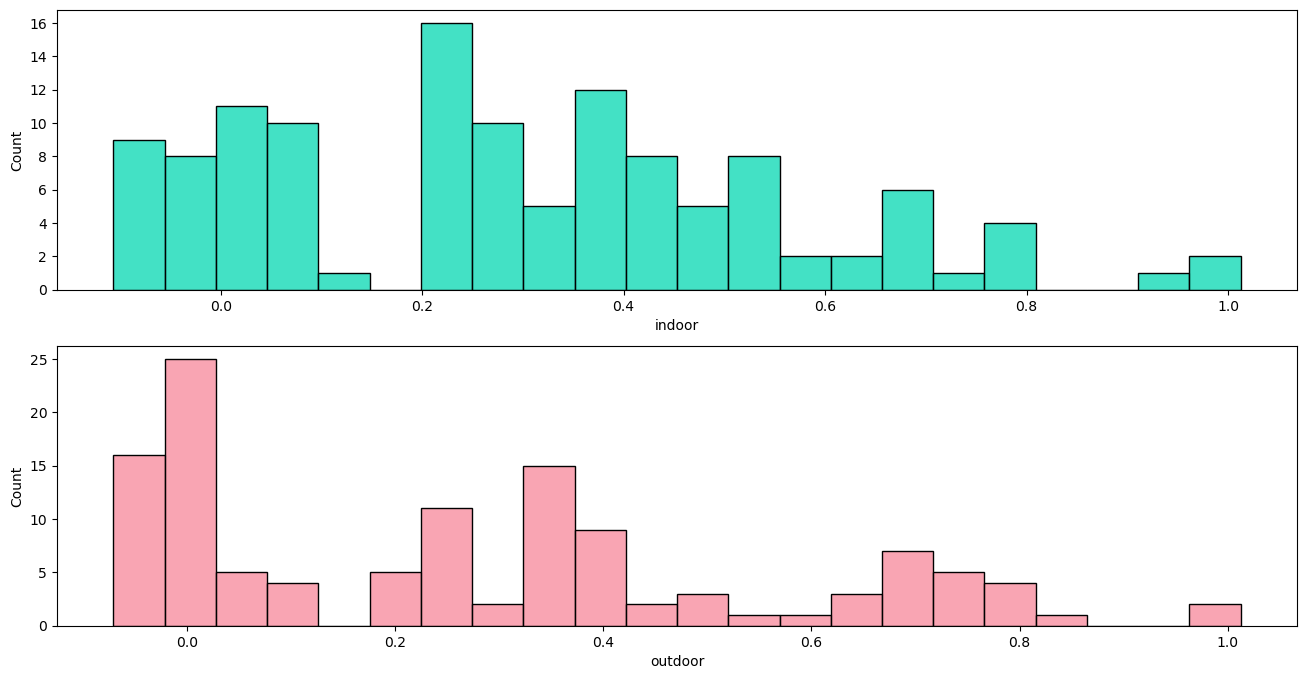

In [14]:
fig, ax = plt.subplots(2,1, figsize=(16,8))
sns.histplot(data=edf, x='indoor', binwidth=0.05, color=XKCD_COLORS['xkcd:aquamarine'], ax=ax[0])
sns.histplot(data=edf, x='outdoor', binwidth=0.05, color=XKCD_COLORS['xkcd:rose pink'], ax=ax[1])

In [5]:
from matplotlib.colors import XKCD_COLORS

In [90]:
fefdf['target'].value_counts()

target
mixed      41
indoor     33
outdoor    32
nontask    15
Name: count, dtype: int64

In [91]:
fefdf.to_csv("./fef_full.csv")

Now we have an extremely small dataset to analyse. We don't know yet if this is the best way to encode the target, but now we know the sequence of events that result in this dataset.